# Saliency Plots

In [1]:
from dna_features_viewer import BiopythonTranslator, GraphicFeature, GraphicRecord
from dna_features_viewer.biotools import annotate_biopython_record
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob, os, yaml, sparse, itertools, subprocess, sys, pickle

import Bio.SeqUtils
import Bio.Data
from Bio import SeqIO
from Bio.Seq import Seq

plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.titlepad'] = 10
import scipy.stats as st

# saliency_utils is in the utils_files directory
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "utils"))
from saliency_utils import *
from inSilicoMut_utils import *
from data_utils import *

from sklearn.linear_model import LinearRegression
BASE_TO_COLUMN = {'A': 0, 'C': 1, 'T': 2, 'G': 3, '-': 4}

results_path = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"
vcf_dir = "/n/scratch3/users/s/sak0914/annotated_VCF"

solo_results = pd.read_excel("/home/sak0914/who-analysis/data/SOLO primary_STATA_ver18Feb2023.xlsx", sheet_name="Sheet1")
who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")
who_variants["gene"] = [val.split("_")[0] for val in who_variants["mutation"].values]

coll_2014 = pd.read_csv("/home/sak0914/who-analysis/data/coll2014_SNP_scheme.tsv", sep="\t")

df_mxf = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/data_for_model.csv")
df_mxf_val = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/validation_data_for_model.csv")

df_rif = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/data_for_model.csv")
df_rif_val = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/validation_data_for_model.csv")

h37Rv = SeqIO.read("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/GCF_000195955.2_ASM19595v2_genomic.gbff", "genbank")
h37Rv_genes = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/mycobrowser_h37rv_genes_v4.csv")

RIF_isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/rpoBC_variants_10543isolates.csv")
MXF_isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/gyrBA_variants_8569isolates.csv")

lineages = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineages.csv")
lineage_mat = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix_Coll2014.csv", index_col=[0])

# RIF_lineage_pred = pd.read_csv("../analysis/Rifampicin/insilico_mutagenesis/lineage_predictions.csv")
# MXF_lineage_pred = pd.read_csv("../analysis/Moxifloxacin/insilico_mutagenesis/lineage_predictions.csv")

4411532


# Pyrazinamide

In [11]:
# _, _ = generate_saliency_plots("PZA",
#                               os.path.join(results_path, "PZA_4Loci"),
#                               ['pncA', 'panD', 'rpsA', 'clpC1'],
#                               fasta_dir="/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/fastas",
#                               cat_to_check=["1"],
#                               binary=False,
#                               save=False,
#                               significance=False,
#                               sig_thresh=0.05,
#                              )

In [6]:
PZA_df.query("Max_Sig==1 | Min_Sig==1")

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
2044,pncA,2289225.0,0.0,-0.001085,0.0,1.0,1,0,0


In [8]:
who_variants.query("genome_index.str.contains('2289225')")

,drug,genome_index,confidence,mutation
31,PZA,2289225,1) Assoc w R,pncA_p.Ile6Thr
826,PZA,2289225,2) Assoc w R - Interim,pncA_p.Ala3_Ile5del
7109,PZA,2289225,3) Uncertain significance,pncA_p.Ile6Ser


4 loci!
Plotting significant saliency scores for pncA using 10 max scores and 10 min scores
Plotting significant saliency scores for panD using 10 max scores and 10 min scores
Plotting significant saliency scores for rpsA using 10 max scores and 10 min scores
Plotting significant saliency scores for clpC1 using 10 max scores and 10 min scores
90 Cat 1 WHO catalog sites for PZA
19 Cat 1 WHO catalog sites not found
Sites not found: [2288724 2288752 2288766 2288777 2288821 2288844 2288869 2288928 2288962
 2288973 2289070 2289072 2289081 2289091 2289142 2289220 2289222 2289225
 2289245]


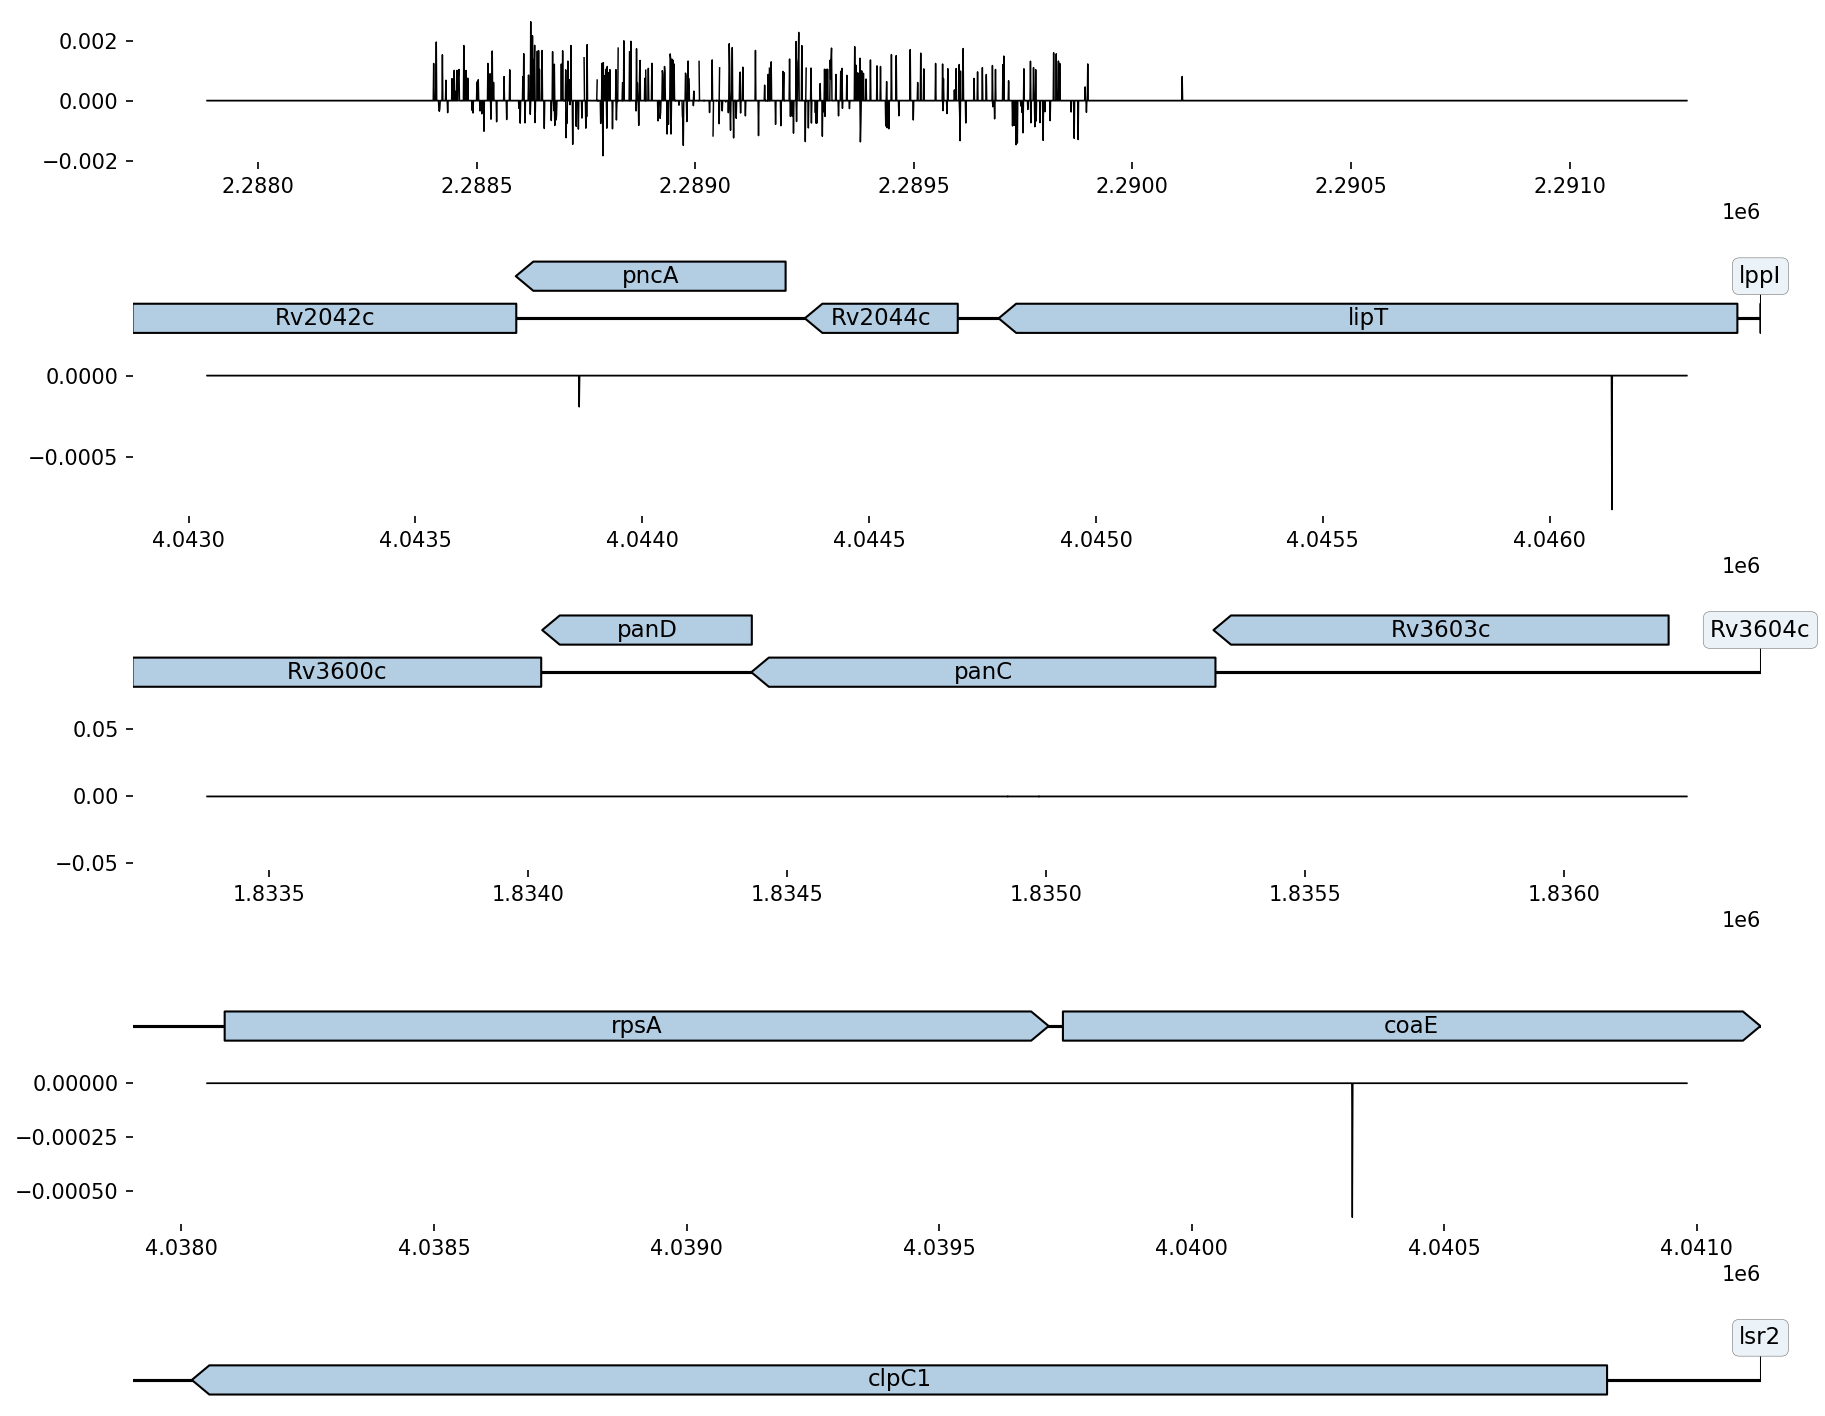

In [30]:
PZA_df, PZA_seqDict = generate_saliency_plots("PZA",
                                              os.path.join(results_path, "PZA_4Loci"),
                                              ['pncA', 'panD', 'rpsA', 'clpC1'],
                                              fasta_dir="/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/PZA/fastas",
                                              cat_to_check=["1"],
                                              binary=False,
                                              save=True,
                                              significance=True,
                                              sig_thresh=0.05,
                                             )

4 loci!
Plotting significant saliency scores for pncA using 10 max scores and 10 min scores
Plotting significant saliency scores for panD using 10 max scores and 10 min scores
Plotting significant saliency scores for rpsA using 10 max scores and 10 min scores
Plotting significant saliency scores for clpC1 using 10 max scores and 10 min scores
90 Cat 1 WHO catalog sites for PZA
26 Cat 1 WHO catalog sites not found
Sites not found: [2288703 2288713 2288766 2288775 2288777 2288778 2288805 2288818 2288826
 2288852 2288883 2288885 2288924 2288933 2288935 2288962 2289031 2289036
 2289038 2289070 2289081 2289089 2289091 2289150 2289220 2289231]


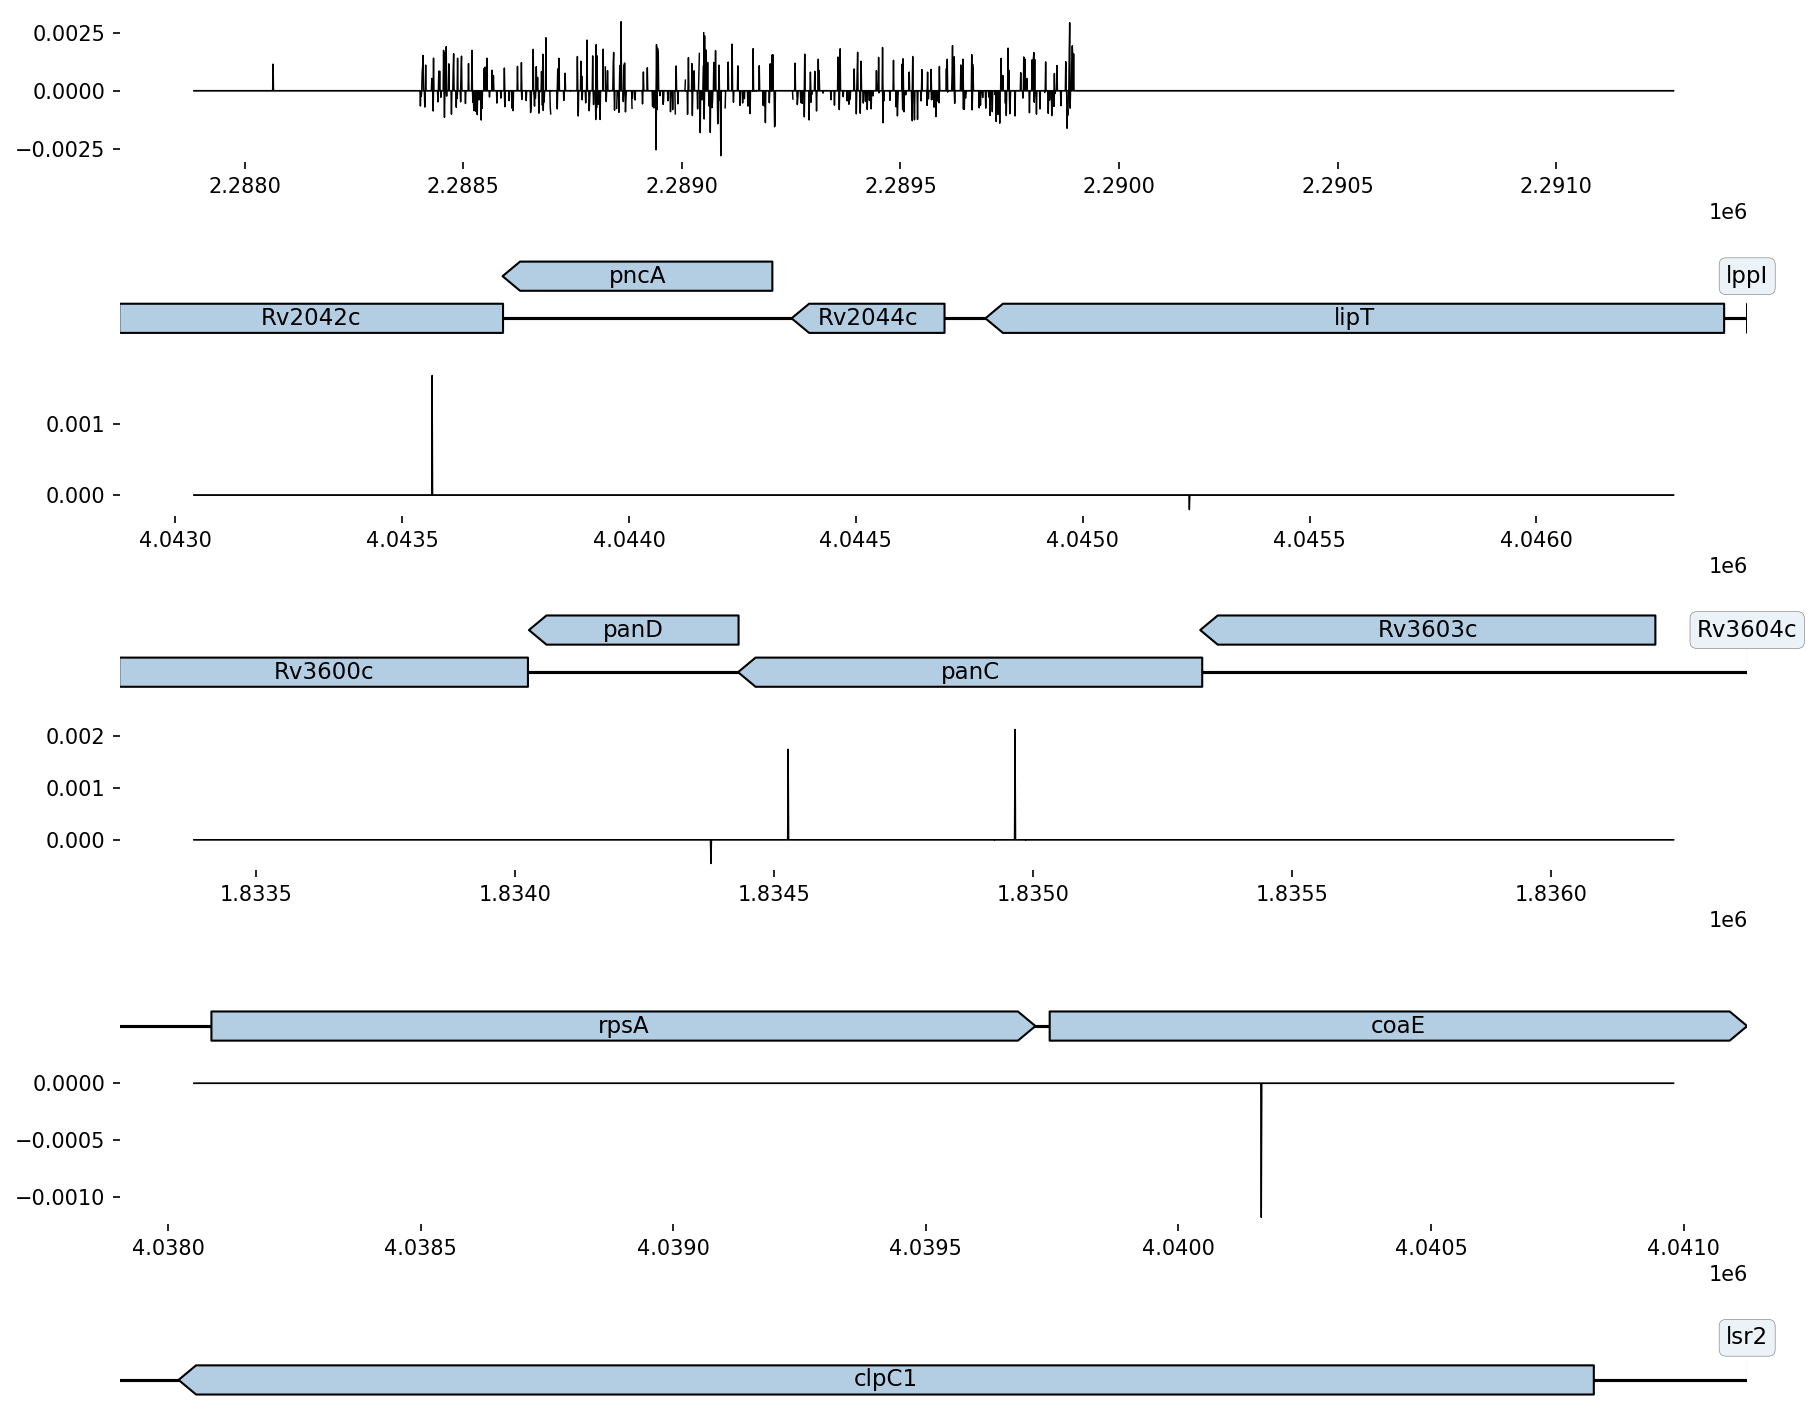

In [21]:
PZA_lineage_df, _ = generate_saliency_plots("PZA",
                                              os.path.join(results_path, "PZA_4Loci_lineage"),
                                              ['pncA', 'panD', 'rpsA', 'clpC1'],
                                              fasta_dir="/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/PZA/fastas",
                                              cat_to_check=["1"],
                                              binary=False,
                                              save=True,
                                              significance=True,
                                              sig_thresh=0.05,
                                             )

In [22]:
PZA_lineage_df.query("Max_Sig==1 | Min_Sig==1")

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
1372,pncA,2289896.0,0.001595,0.000000,1.0,0.0,0,0,0
1374,pncA,2289894.0,0.001489,0.000000,1.0,0.0,0,0,0
1375,pncA,2289893.0,0.001936,0.000000,1.0,0.0,0,0,0
1376,pncA,2289892.0,0.001555,0.000000,1.0,0.0,0,0,0
1380,pncA,2289888.0,0.000000,-0.000755,0.0,1.0,0,0,0
...,...,...,...,...,...,...,...,...,...
6191,panD,4043566.0,0.001687,0.000000,1.0,0.0,0,0,0
7715,rpsA,1834378.0,0.000000,-0.000458,0.0,1.0,0,0,0
7864,rpsA,1834527.0,0.001743,0.000000,1.0,0.0,0,0,0
8304,rpsA,1834965.0,0.002125,0.000000,1.0,0.0,0,0,0


In [32]:
PZA_df.Max.max(), PZA_lineage_df.Max.max(), PZA_new_loci_df.Max.max()

(0.002629475202411413, 0.00297668669372797, 0.0039823465049266815)

5 loci!


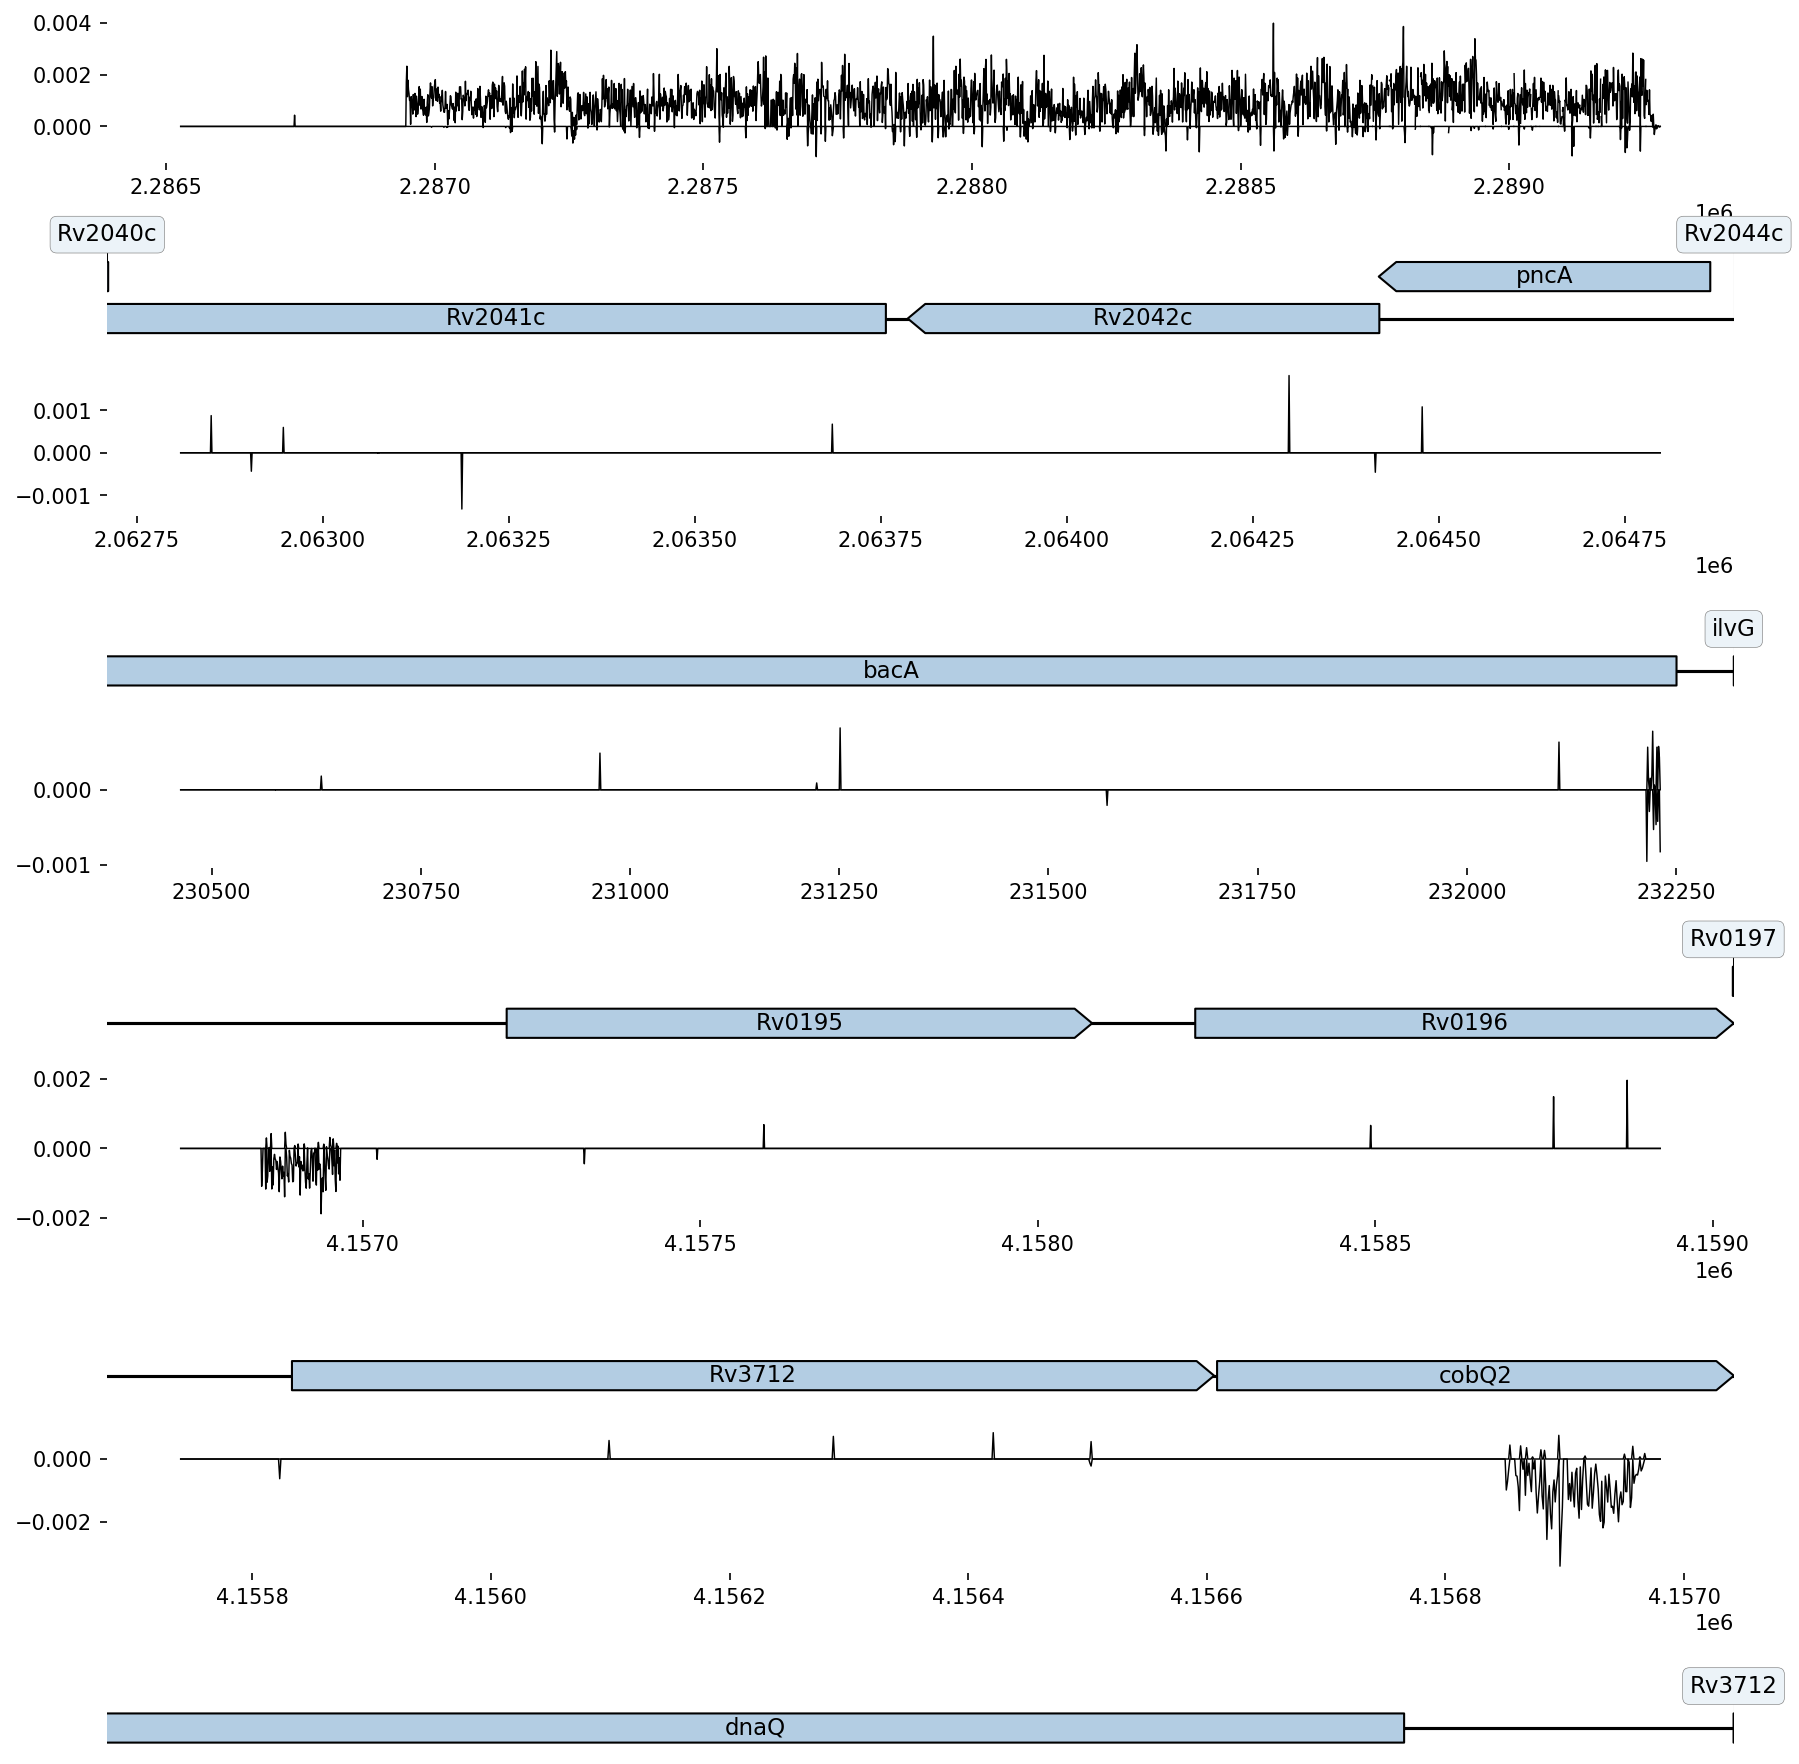

90 Cat 1 WHO catalog sites for PZA
4 Cat 1 WHO catalog sites not found
Sites not found: [2288752 2288806 2289103 2289207]


In [25]:
PZA_new_loci_df, _ = generate_saliency_plots("PZA",
                                              os.path.join(results_path, "PZA_5Loci"),
                                              ['pncA', 'bacA', 'Rv0195_Rv0196', 'Rv3712', 'dnaQ'],
                                              fasta_dir="/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/PZA/TRUST/fastas",
                                              cat_to_check=["1"],
                                              binary=False,
                                              save=False,
                                              significance=False,
                                              sig_thresh=0.05,
                                             )

In [12]:
# _, _ = generate_saliency_plots("PZA",
                                 #  os.path.join(results_path, "PZA_4Loci_lineage"),
                                 #  ['pncA', 'panD', 'rpsA', 'clpC1'],
                                 #  fasta_dir="/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/PZA/fastas",
                                 #  cat_to_check=["1"],
                                 #  binary=False,
                                 #  save=False,
                                 #  significance=False,
                                 #  sig_thresh=0.05,
                                 # )

# Ethambutol

2 loci!
Plotting significant saliency scores for embCAB using 10 max scores and 10 min scores
Plotting significant saliency scores for aftB_ubiA using 10 max scores and 10 min scores
11 Cat 1/2 WHO catalog sites for EMB
1 Cat 1/2 WHO catalog sites not found
Sites not found: [4248002]


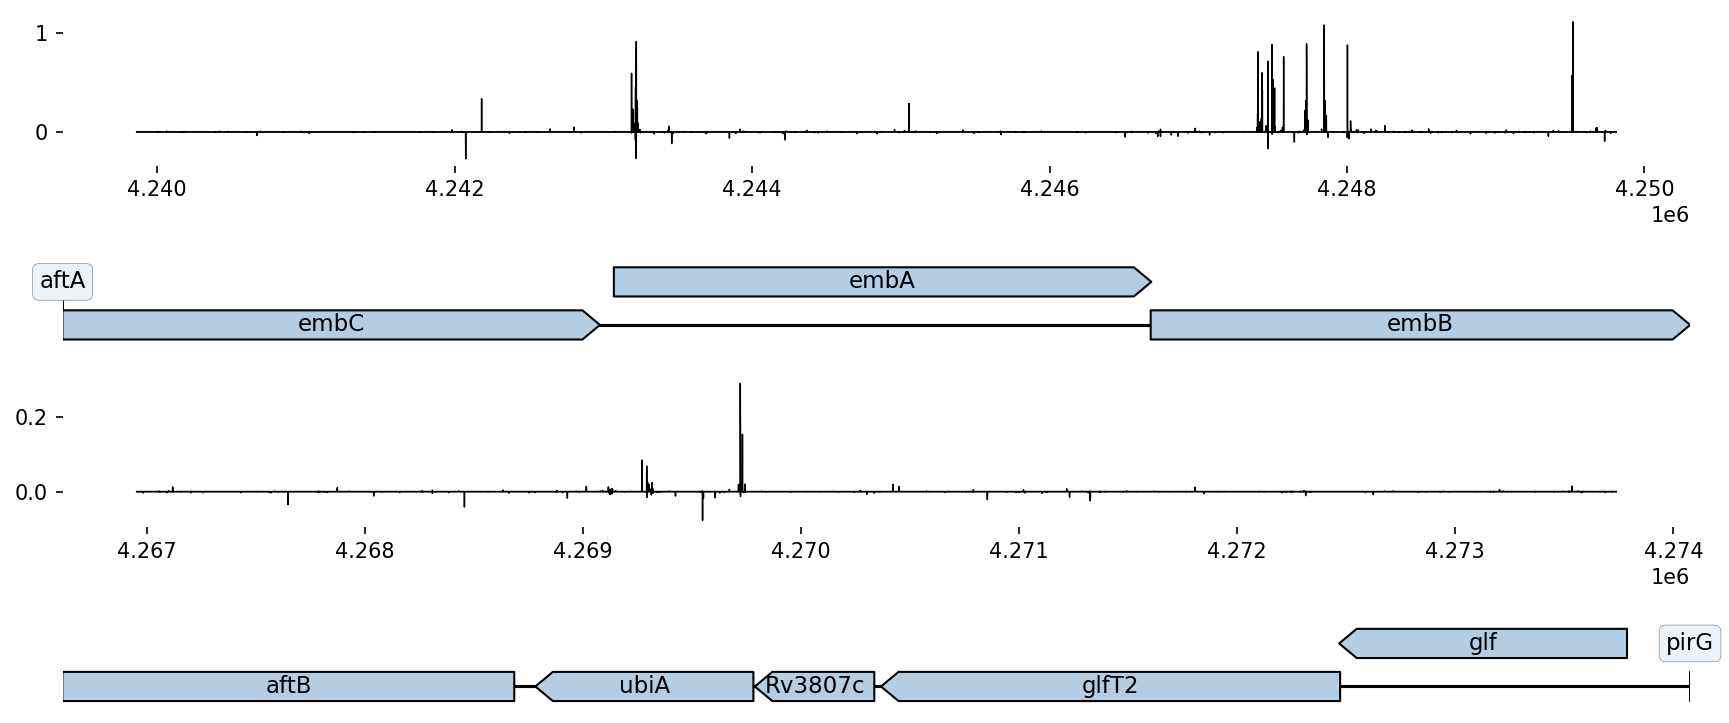

In [2]:
EMB_df, EMB_seqDict = generate_saliency_plots("EMB",
                                              os.path.join(results_path, "EMB_2Loci"),
                                              ['embCAB', 'aftB_ubiA'],
                                              fasta_dir="/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/EMB/fastas",
                                              cat_to_check=["1", "2"],
                                              binary=False,
                                              save=True,
                                              significance=True,
                                              sig_thresh=0.05,
                                             )

2 loci!
Plotting significant saliency scores for embCAB using 10 max scores and 10 min scores
Plotting significant saliency scores for aftB_ubiA using 10 max scores and 10 min scores
11 Cat 1/2 WHO catalog sites for EMB
1 Cat 1/2 WHO catalog sites not found
Sites not found: [4248002]


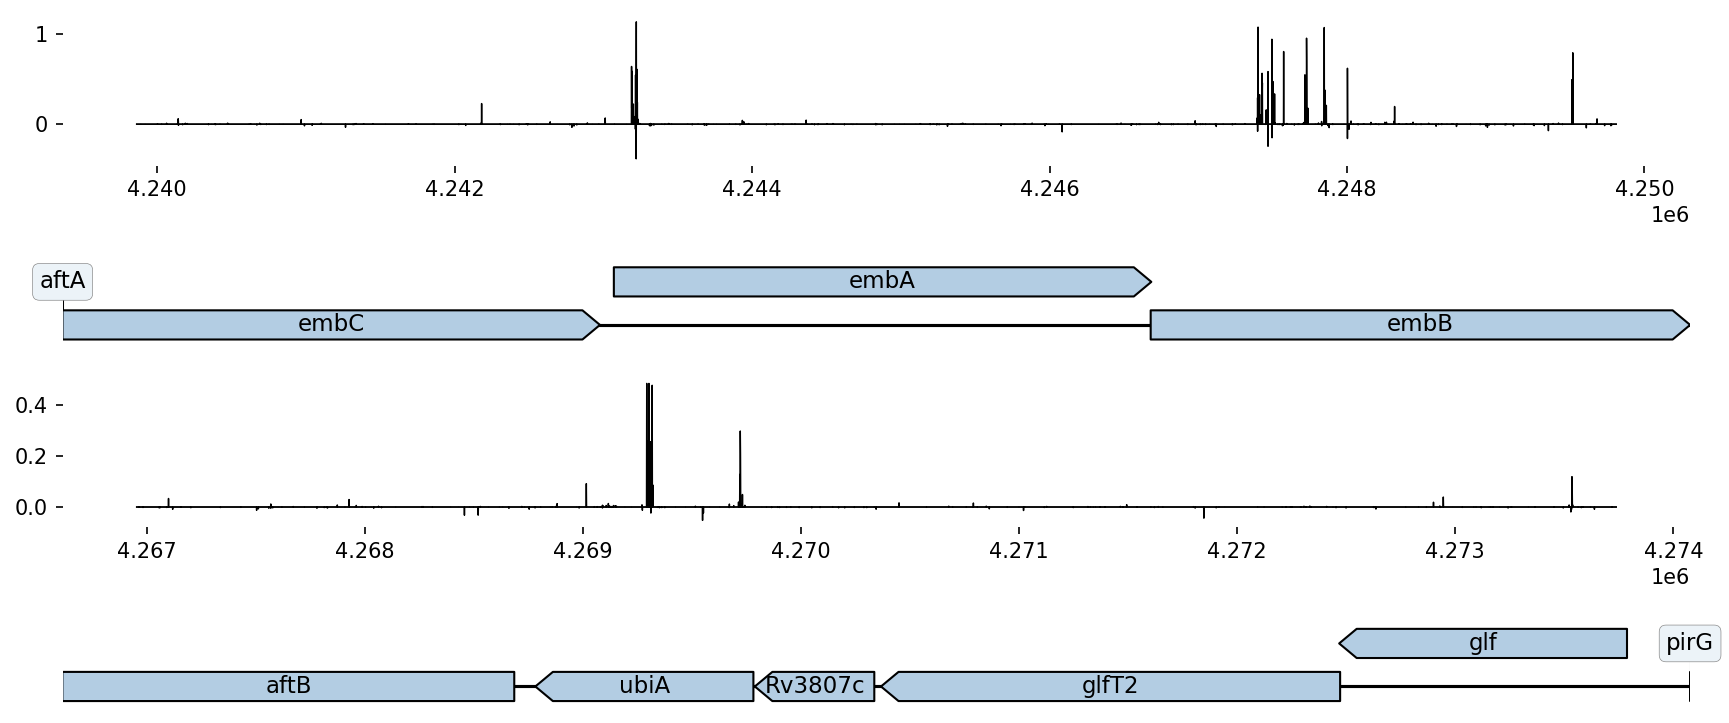

In [4]:
EMB_lineage_df, _ = generate_saliency_plots("EMB",
                                          os.path.join(results_path, "EMB_2Loci_lineage"),
                                          ['embCAB', 'aftB_ubiA'],
                                          fasta_dir="/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/EMB/fastas",
                                          cat_to_check=["1", "2"],
                                          binary=False,
                                          save=True,
                                          significance=True,
                                          sig_thresh=0.05,
                                         )

In [11]:
who_variants.query("drug=='EMB' & gene=='ubiA'").confidence.unique()

array(['3) Uncertain significance', '5) Not assoc w R'], dtype=object)

In [13]:
who_variants.query("drug=='EMB' & confidence=='2) Assoc w R - Interim'")

,drug,genome_index,confidence,mutation,gene
308,EMB,4246734,2) Assoc w R - Interim,embB_p.Leu74Arg,embB


In [5]:
who_variants.query("drug=='EMB' & confidence=='1) Assoc w R'")

,drug,genome_index,confidence,mutation
51,EMB,4247469,1) Assoc w R,embB_p.Tyr319Cys
52,EMB,4247729,1) Assoc w R,embB_p.Gly406Cys
53,EMB,4247495,1) Assoc w R,embB_p.Asp328Tyr
54,EMB,4248002,1) Assoc w R,embB_p.Gln497Lys
55,EMB,4247429,1) Assoc w R,embB_p.Met306Leu
56,EMB,4247729,1) Assoc w R,embB_p.Gly406Ser
57,EMB,4247730,1) Assoc w R,embB_p.Gly406Asp
113,EMB,4247469,1) Assoc w R,embB_p.Tyr319Ser
154,EMB,4247730,1) Assoc w R,embB_p.Gly406Ala
156,EMB,4243221,1) Assoc w R,embA_c.-12C>T


In [15]:
EMB_df.query("Pos==4248002")

,Gene,Pos,Max,Min,WHO,Coll_2014,Freschi_2020
8182,embCAB,4248002.0,0.0,-0.05805,1,0,0


In [7]:
EMB_df.query("Pos==4243221")

,Gene,Pos,Max,Min,WHO,Coll_2014,Freschi_2020
3385,embCAB,4243221.0,0.781274,-0.268696,1,0,0


# Isoniazid

In [4]:
os.path.join(results_path, "INH_4Loci")

'/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/INH_4Loci'

In [5]:
# INH_df, INH_seqDict = generate_saliency_plots("INH",
#                                               os.path.join(results_path, "INH_4Loci"),
#                                               ['katG', 'inhA', 'kasA', 'ahpC'],
#                                               fasta_dir="/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/INH/fastas",
#                                               cat_to_check=["1"],
#                                               binary=False,
#                                               save=True,
#                                               significance=True,
#                                               sig_thresh=0.05,
#                                              )

In [6]:
INH_lineage_df, _ = generate_saliency_plots("INH",
                                              os.path.join(results_path, "INH_4Loci_lineage"),
                                              ['katG', 'inhA', 'kasA', 'ahpC'],
                                              fasta_dir="/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/INH/fastas",
                                              cat_to_check=["1"],
                                              binary=False,
                                              save=True,
                                              significance=True,
                                              sig_thresh=0.05,
                                             )

4 loci!


FileNotFoundError: [Errno 2] No such file or directory: '/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/INH_4Loci_lineage/saliency/quant/scores_max.npy'

# Rifampicin

1 loci!
Plotting significant saliency scores using 10 max scores and 10 min scores
17 Cat 1 WHO catalog sites for RIF
1 Cat 1 WHO catalog sites not found
Sites not found: [761134]


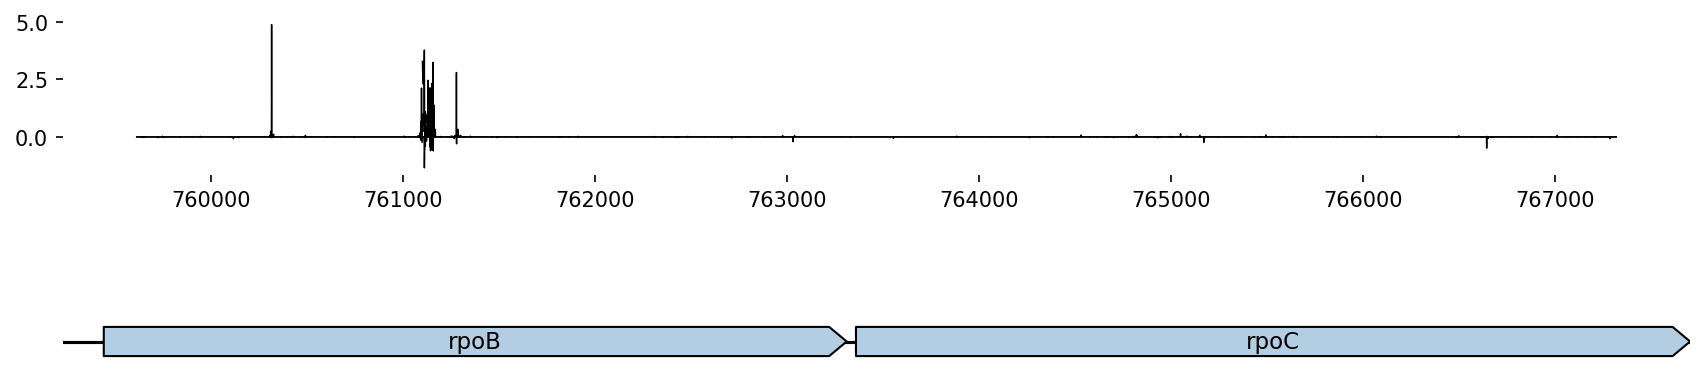

In [4]:
RIF_rpoBC_df, rpoBC_seqDict = generate_saliency_plots("RIF",
                                                      os.path.join(results_path, "RIF_rpoBC"),
                                                      ["rpoBC"],
                                                      cat_to_check=["1"],
                                                      binary=False,
                                                      save=True,
                                                      significance=True,
                                                      sig_thresh=0.05,
                                                     )


RIF_rpoBC_scores = sparse.load_npz(os.path.join(results_path, "RIF_rpoBC/saliency/quant/genetic_scores_unpooled_nuc.npy.npz")).todense()

# saliency_save = RIF_rpoBC_df.copy()
# del saliency_save["Coll_2014"]
# del saliency_save["Freschi_2020"]
# del saliency_save["WHO"]
# saliency_save.to_csv("../analysis/Rifampicin/rpoBC_saliency_results.csv", index=False)

# rpoBC_seqDict["rpoBC"].to_csv("/home/sak0914/MtbQuantCNN/analysis/Rifampicin/rpoBC_seqdf.csv")

In [135]:
def get_saliency_score_single_mutation(drug, mutation, saliency_df, seq_df, saliency_scores_by_nuc):

    vcf_reader = vcf.Reader(filename=f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/{drug}/inSilico_analysis/synthetic_VCF/{mutation}.vcf")

    scores_lst = []
    
    for record in vcf_reader:
        pos = record.POS
        alt = str(record.ALT[0])

        # if site has a significant positive score and an insignificant negative score, get it
        if saliency_df.loc[saliency_df["Pos"]==pos, "Max_Sig"].values[0] == 1:# and saliency_df.loc[saliency_df["Pos"]==pos, "Min_Sig"].values[0] == 0:

            # keep only alleles that are present in at least 2 isolates (there are some in only 1)
            if len(seq_df.loc[seq_df[pos] == alt]) > 1:

                idx = saliency_df.query("Pos==@pos").index.values[0] 
                max_scores = np.max(saliency_scores_by_nuc[:, :, idx, 0], axis=0)
                max_scores_dict = dict(zip(BASE_TO_COLUMN.keys(), max_scores))
        
                assert seq_df.loc['MT_H37Rv', pos] == record.REF
        
                scores_lst.append(max_scores_dict[alt])

            else:
                scores_lst.append(0)

        # if not, set it as 0
        else:
            scores_lst.append(0)
            
    return np.mean(scores_lst)
    
    
    
def plot_pred_MIC_by_saliency(drug, insilico_pred_df, saliency_df, seq_df, saliency_scores_by_nuc, saveName=None):
    '''
    Only plots SNPs and missense mutations for simplicity. For MNPs, would have to combine saliency scores across nucleotides,  
    '''

    for i, row in insilico_pred_df.iterrows():
        # exclude MT_H37Rv
        if not pd.isnull(row["genome_index"]):
            # ignore indels for now
            if "del" not in row["mutation"] and "ins" not in row["mutation"] and "dup" not in row["mutation"]:
                insilico_pred_df.loc[i, "saliency_score"] = get_saliency_score_single_mutation(drug, row["mutation"], saliency_df, seq_df, saliency_scores_by_nuc)
                
    # NaNs are indels, 0 scores are no significant saliency score, so exclude both before plotting
    plot_df = insilico_pred_df.loc[~pd.isnull(insilico_pred_df["saliency_score"])].query("saliency_score > 0")
        
    fig, ax = plt.subplots()
    sns.scatterplot(data=plot_df,
                    x="saliency_score",
                    y="CNN_log_MIC",
                    hue="confidence",
                    palette="colorblind",
                    alpha=0.8,
                    edgecolor="black",
                    linewidth=0.5,
                    s=30,
                    ax=ax
                   )
    
    plt.axhline(y=-1, label="CC = 0.5 µg/mL", color="black", linestyle="--", linewidth=0.8, zorder=0)
    
    rho, pval = st.spearmanr(plot_df["saliency_score"], plot_df['CNN_log_MIC'])
    plt.xlabel("Max. Saliency Score")
    plt.ylabel("Predicted log2-MIC")
    plt.title(f"{len(plot_df)} SNP Missense Mutations, Spearman R = {np.round(rho, 2)}, pval = {np.round(pval, 4)}")
    # plt.legend()
    
    legend = plt.legend(title="", fontsize='7')
    
    #change the marker size manually for both lines
    for i, _ in enumerate(plot_df.confidence.unique()):
        legend.legendHandles[i]._sizes = [15]
    #ax.set_yticks(ticks=ax.get_yticks(), labels=np.round(np.exp2(ax.get_yticks()), 2))
    sns.despine()

    if saveName is None:
        plt.show()
    else:
        if not os.path.isdir(os.path.dirname(saveName)):
            os.makedirs(os.path.dirname(saveName))
        plt.savefig(saveName, dpi=300)

    return insilico_pred_df

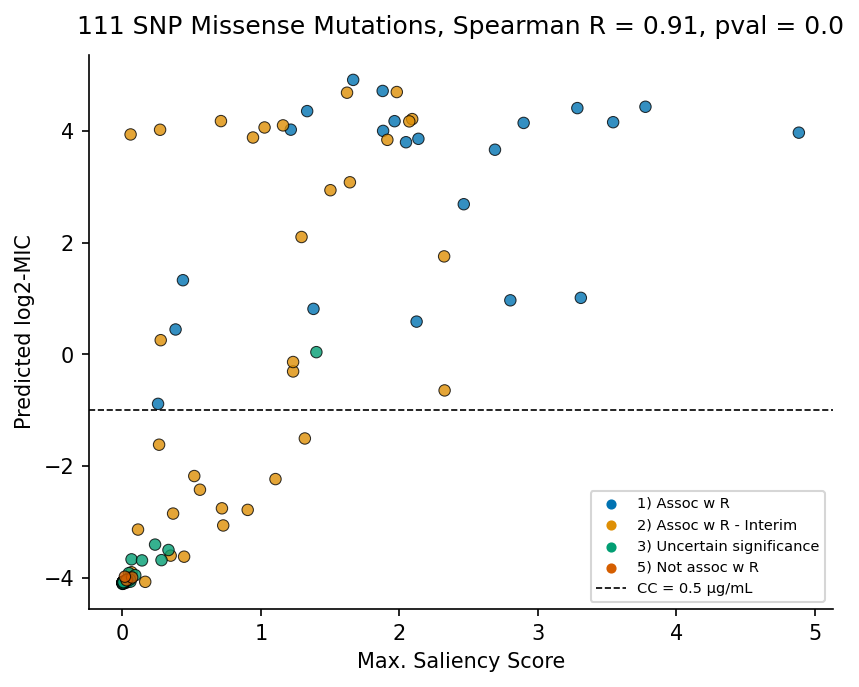

In [137]:
RIF_pred = pd.read_csv("../analysis/Rifampicin/insilico_mutagenesis/rpoBC_WHO_predictions.csv")

RIF_pred = plot_pred_MIC_by_saliency("RIF", RIF_pred, RIF_rpoBC_df, rpoBC_seqDict['rpoBC'], RIF_rpoBC_scores, saveName="../analysis/Rifampicin/insilico_mutagenesis/predictions_vs_saliency.png"
                                    )

# Indels with High Positive Scores

In [120]:
RIF_isolate_variants.query("Isolate=='ERR4828591'")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation,RIF_midpoint,category,new_variant
13667,759627.0,A,ACTTGACACCGTGGTCTTAGTC,PASS,0.46,mazF2,upstream_gene_variant,c.-4635_-4634insGACTAAGACCACGGTGTCAAG,.,ERR4828591,mazF2_c.-4635_-4634insGACTAAGACCACGGTGTCAAG,0.03,train,c.-4635_-4634insGACTAAGACCACGGTGTCAAG
13668,759648.0,C,CCTTGACACCGTGGTCTTAGTC,PASS,0.76,mazF2,upstream_gene_variant,c.-4656_-4655insGACTAAGACCACGGTGTCAAG,.,ERR4828591,mazF2_c.-4656_-4655insGACTAAGACCACGGTGTCAAG,0.03,train,c.-4656_-4655insGACTAAGACCACGGTGTCAAG
13669,763031.0,T,C,PASS,1.00,rpoB,synonymous_variant,c.3225T>C,p.Ala1075Ala,ERR4828591,rpoB_c.3225T>C,0.03,train,c.3225T>C


In [123]:
df_rif.query("ROLLINGDB_ID=='ERR4828591'")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ID,ISOLATION_LOCATION,DB_OF_ORIGIN,STUDY_NAME,STUDY_PMID,TESTING_LOCATION,MEDIA,RIF,RIF_lower_bound,RIF_midpoint,RIF_upper_bound,RIF_quality,Path,Coll2014,Binary,Lineage,category
6801,ERR4828591,ERS5317664,site.08.subj.24TB00-047.lab.2433.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,<=0.06,0.0,0.03,0.06,HIGH,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,2.2.1,0,2,original_train_set


In [119]:
RIF_isolate_variants.query("POS==759648")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation,RIF_midpoint,category,new_variant
4052,759648.0,C,T,PASS,1.00,mazF2,upstream_gene_variant,c.-4655G>A,.,ERR3287654,mazF2_c.-4655G>A,0.03,train,c.-4655G>A
9492,759648.0,C,CT,PASS,1.01,mazF2,upstream_gene_variant,c.-4656_-4655insA,.,ERR4810667,mazF2_c.-4656_-4655insA,0.03,train,c.-4656_-4655insA
13668,759648.0,C,CCTTGACACCGTGGTCTTAGTC,PASS,0.76,mazF2,upstream_gene_variant,c.-4656_-4655insGACTAAGACCACGGTGTCAAG,.,ERR4828591,mazF2_c.-4656_-4655insGACTAAGACCACGGTGTCAAG,0.03,train,c.-4656_-4655insGACTAAGACCACGGTGTCAAG


In [118]:
RIF_isolate_variants.query("POS in [761097, 761102, 761106, 761813]").drop_duplicates("mutation").sort_values("POS")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation,RIF_midpoint,category,new_variant
3143,761097.0,A,AGCC,PASS,0.98,rpoB,disruptive_inframe_insertion,c.1292_1294dupGCC,p.Ser431_Gln432insArg,ERR2510627,rpoB_p.Ser431_Gln432insArg,4.000,test,p.Ser431_Gln432insArg
17844,761097.0,A,G,PASS,1.00,rpoB,missense_variant,c.1291A>G,p.Ser431Gly,ERR4831654,rpoB_p.Ser431Gly,8.000,train,p.Ser431Gly
23220,761097.0,A,C,Amb,0.27,rpoB,missense_variant,c.1291A>C,p.Ser431Arg,SAMN02360565,rpoB_p.Ser431Arg,16.000,train,p.Ser431Arg
1162,761102.0,A,ATTC,PASS,0.93,rpoB,conservative_inframe_insertion,c.1297_1299dupTTC,p.Phe433dup,C447,rpoB_p.Phe433dup,6.000,validation,p.Phe433dup
2803,761102.0,A,T,PASS,1.00,rpoB,missense_variant,c.1296A>T,p.Gln432His,ERR2510525,rpoB_p.Gln432His,3.000,train,p.Gln432His
8001,761102.0,ATTCATGGAC,A,PASS,1.00,rpoB,conservative_inframe_deletion,c.1297_1305delTTCATGGAC,p.Phe433_Asp435del,ERR4797676,rpoB_p.Phe433_Asp435del,4.000,train,p.Phe433_Asp435del
19534,761106.0,A,C,PASS,1.00,rpoB,missense_variant,c.1300A>C,p.Met434Leu,JPN-R2012-0083,rpoB_p.Met434Leu,0.375,validation,p.Met434Leu
19800,761106.0,A,G,PASS,1.00,rpoB,missense_variant,c.1300A>G,p.Met434Val,KOR-K2016-0113,rpoB_p.Met434Val,28.000,validation,p.Met434Val
20376,761106.0,A,ATGG,PASS,0.97,rpoB,disruptive_inframe_insertion,c.1301_1303dupTGG,p.Met434_Asp435insVal,NLA009600800,rpoB_p.Met434_Asp435insVal,5.000,train,p.Met434_Asp435insVal
23022,761106.0,ATGG,A,PASS,0.71,rpoB,disruptive_inframe_deletion,c.1301_1303delTGG,p.Met434_Asp435delinsAsn,RB00104514,rpoB_p.Met434_Asp435delinsAsn,12.000,validation,p.Met434_Asp435delinsAsn


In [102]:
pos = 761106
idx = RIF_rpoBC_df.query("Pos==@pos").index.values[0] 
print(f"Ref: {rpoBC_seqDict['rpoBC'].loc['MT_H37Rv', pos]}")
max_scores = np.max(RIF_rpoBC_scores[:, :, idx, 0], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), max_scores))

Ref: A


{'A': 0.0, 'C': 0.0, 'T': 0.0, 'G': 0.0, '-': 0.903983}

In [12]:
# RIF_rpoBC_lineage_df, _ = generate_saliency_plots("RIF",
#                                                       os.path.join(results_path, "RIF_rpoBC_lineage"),
#                                                       ["rpoBC"],
#                                                       plot_thresh=10,
#                                                       cat_to_check=["1"],
#                                                       binary=False,
#                                                       save=True,
#                                                       significance=True,
#                                                       sig_thresh=0.05,
#                                                      )

In [8]:
print(RIF_rpoBC_lineage_df.query("Max > 0 | Min < 0").shape)
print(RIF_rpoBC_lineage_df.query("(Max_Sig == 1 & Max > 0) | (Min_Sig == 1 & Min < 0)").shape)

(772, 9)
(626, 9)


In [2]:
# RIF_rpoBC_binary_df, _ = generate_saliency_plots("RIF",
#                                                  os.path.join(results_path, "RIF_rpoBC"),
#                                                  ["rpoBC"],
#                                                  plot_thresh=20,
#                                                  cat_to_check=["1"],
#                                                  binary=True,
#                                                  save=True,
#                                                  significance=True,
#                                                  sig_thresh=0.05,
#                                                 )

In [10]:
print(RIF_rpoBC_binary_df.query("Max > 0 | Min < 0").shape)
print(RIF_rpoBC_binary_df.query("(Max_Sig == 1 & Max > 0) | (Min_Sig == 1 & Min < 0)").shape)

(772, 9)
(722, 9)


In [152]:
max_thresh = RIF_rpoBC_df.query("Max != 0").Max.mean()
min_thresh = RIF_rpoBC_df.query("Min != 0").Min.mean()
RIF_rpoBC_df.query("(Max_Sig == 1 & Max > @max_thresh) | (Min_Sig == 1 & Min < @min_thresh)").shape

(86, 9)

In [151]:
max_thresh = RIF_rpoBC_binary_df.query("Max != 0").Max.mean()
min_thresh = RIF_rpoBC_binary_df.query("Min != 0").Min.mean()
RIF_rpoBC_binary_df.query("(Max_Sig == 1 & Max > @max_thresh) | (Min_Sig == 1 & Min < @min_thresh)").shape

(83, 9)

# Levofloxacin

1 loci!
Plotting significant saliency scores for gyrBA using 10 max scores and 10 min scores
11 Cat 1/2 WHO catalog sites for LEV
2 Cat 1/2 WHO catalog sites not found
Sites not found: [6734 6741]


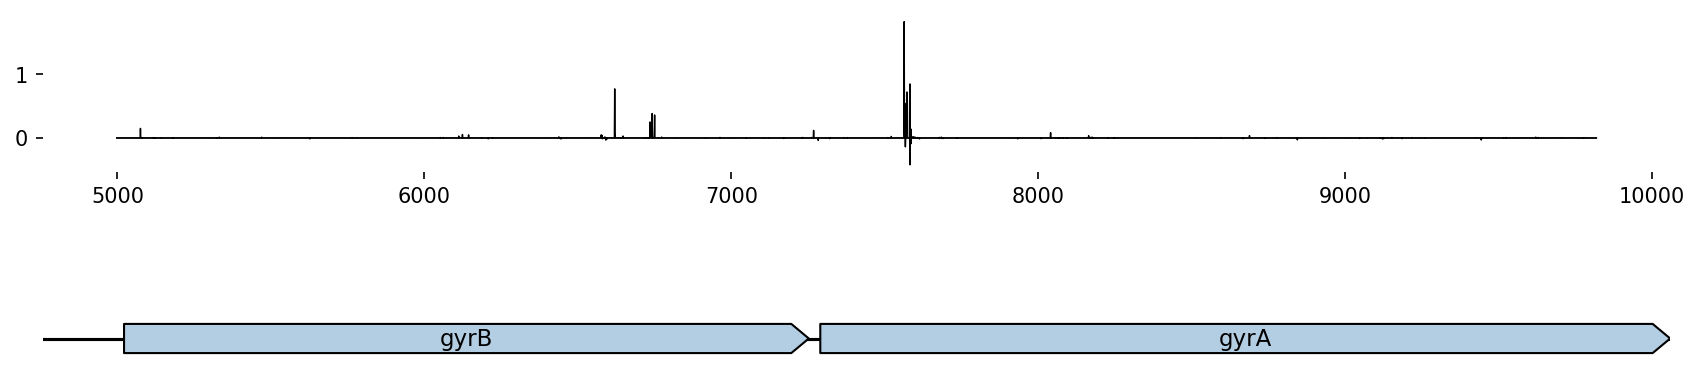

In [3]:
LEV_gyrBA_df, LEV_gyrBA_seqDict = generate_saliency_plots("LEV",
                                                          os.path.join(results_path, "LEV_gyrBA"),
                                                          ["gyrBA"],
                                                          cat_to_check=["1", "2"],
                                                          fasta_dir="/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/LEV/fastas",
                                                          binary=False,
                                                          save=True,
                                                          significance=True,
                                                          sig_thresh=0.05,
                                                         )

In [ ]:
LEV_gyrBA_lineage_df, _ = generate_saliency_plots("LEV",
                                                  os.path.join(results_path, "LEV_gyrBA_lineage"),
                                                  ["gyrBA"],
                                                  cat_to_check=["1", "2"],
                                          fasta_dir="/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/LEV/fastas",
                                                  binary=False,
                                                  save=True,
                                                  significance=True,
                                                  sig_thresh=0.05,
                                                 )

# Moxifloxacin

1 loci!
Plotting significant saliency scores for gyrBA using 10 max scores and 10 min scores
11 Cat 1/2 WHO catalog sites for MXF
CNN found all Cat 1/2 WHO catalog sites for MXF


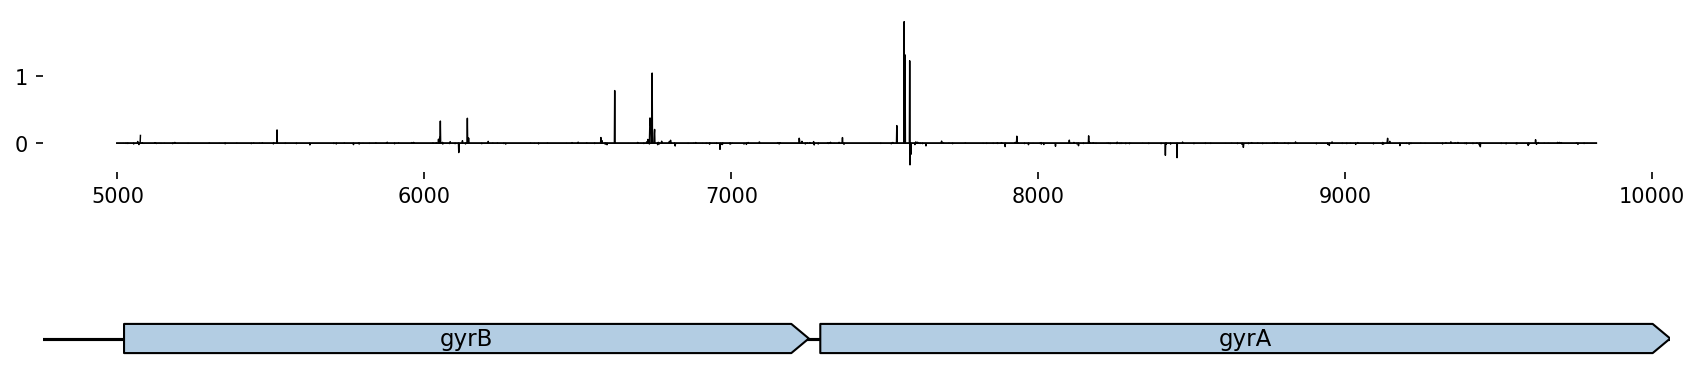

In [4]:
MXF_gyrBA_df, gyrBA_seqDict = generate_saliency_plots("MXF",
                                                      os.path.join(results_path, "MXF_gyrBA"),
                                                      ["gyrBA"],
                                                      cat_to_check=["1", "2"],
                                                      fasta_dir="/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/fastas",
                                                      binary=False,
                                                      save=True,
                                                      significance=True,
                                                      sig_thresh=0.05
                                                     )

# MXF_gyrBA_df.to_csv("/home/sak0914/MtbQuantCNN/analysis/Moxifloxacin/gyrBA_saliency_results.csv", index=False)
# gyrBA_seqDict["gyrBA"].to_csv("/home/sak0914/MtbQuantCNN/analysis/Moxifloxacin/gyrBA_seqdf.csv")

In [7]:
print(MXF_gyrBA_df.query("Max > 0 | Min < 0").shape)
print(MXF_gyrBA_df.query("(Max_Sig == 1 & Max > 0) | (Min_Sig == 1 & Min < 0)").shape)

(490, 9)
(341, 9)


1 loci!
Plotting significant saliency scores for gyrBA using 10 max scores and 10 min scores
6 Cat 1 WHO catalog sites for MXF
CNN found all Cat 1 WHO catalog sites for MXF


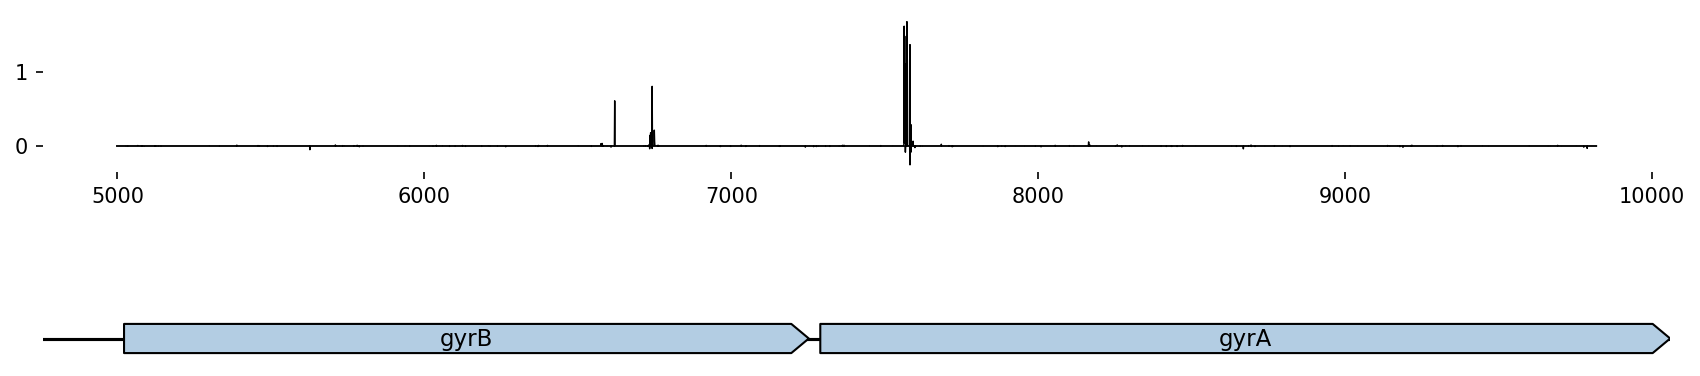

In [36]:
MXF_gyrBA_lineage_df, gyrBA_seqDict = generate_saliency_plots("MXF",
                                                              os.path.join(results_path, "MXF_gyrBA_lineage"),
                                                              ["gyrBA"],
                                                              cat_to_check=["1"],
                                                              fasta_dir="/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/fastas",
                                                              binary=False,
                                                              save=True,
                                                              significance=True
                                                             )

# MXF_gyrBA_lineage_scores = sparse.load_npz(os.path.join(results_path, "MXF_gyrBA_lineage/saliency/quant/genetic_scores_unpooled_nuc.npy.npz")).todense()

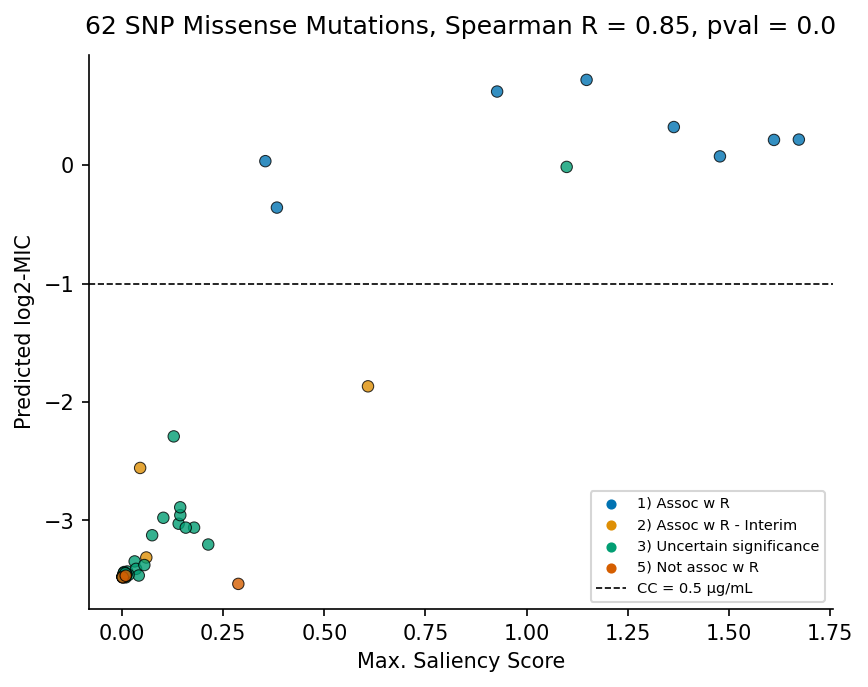

In [7]:
MXF_pred = pd.read_csv("../analysis/Moxifloxacin/insilico_mutagenesis/gyrBA_WHO_predictions.csv")

MXF_pred = plot_pred_MIC_by_saliency("MXF", MXF_pred, MXF_gyrBA_lineage_df, gyrBA_seqDict['gyrBA'], MXF_gyrBA_lineage_scores, saveName="../analysis/Moxifloxacin/insilico_mutagenesis/predictions_vs_saliency.png")

In [23]:
pos = 6742
print(f"Ref: {gyrBA_seqDict['gyrBA'].loc['MT_H37Rv', pos]}")
idx = MXF_gyrBA_lineage_df.query("Pos==@pos").index.values[0] 
max_scores = np.max(MXF_gyrBA_lineage_scores[:, :, idx, 0], axis=0)
max_scores_dict = dict(zip(BASE_TO_COLUMN.keys(), max_scores))
max_scores_dict

Ref: A


{'A': 0.0, 'C': 0.80232906, 'T': 0.0, 'G': 0.0, '-': 0.0}

In [26]:
gyrBA_seqDict['gyrBA'][pos].unique()

array(['A', 'C', 'N', 'T'], dtype=object)

In [28]:
gyrBA_seqDict['gyrBA'][pos].value_counts()

6742.0
A    7246
C      16
N       6
T       2
Name: count, dtype: int64

In [31]:
who_variants.query("drug=='MXF' & mutation.str.contains('Glu501')")

,drug,genome_index,confidence,mutation
184,MXF,6742,1) Assoc w R,gyrB_p.Glu501Asp
705,MXF,6741,2) Assoc w R - Interim,gyrB_p.Glu501Val
6463,MXF,6741,3) Uncertain significance,gyrB_p.Glu501Ala
6513,MXF,6741,3) Uncertain significance,gyrB_p.Glu501Gly


In [38]:
MXF_pred.query("confidence=='2) Assoc w R - Interim'")

,CNN_log_MIC,Reg_log_MIC,mutation,confidence,genome_index,saliency_score
9,-3.160314,-3.112356,gyrB_p.Glu501Val,2) Assoc w R - Interim,6741,0.000000
10,-3.274468,-2.716722,gyrB_p.Asn499Asp,2) Assoc w R - Interim,6734,0.000000
11,-3.313097,-1.907147,gyrB_p.Ala504Val,2) Assoc w R - Interim,6750,0.059861
12,-2.556720,-2.201073,gyrA_p.Gly88Ala,2) Assoc w R - Interim,7564,0.044636
13,-1.867081,-1.171659,gyrB_p.Asp461Asn,2) Assoc w R - Interim,6620,0.607959


In [39]:
MXF_gyrBA_lineage_df.query("Pos==7564")

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
2577,gyrBA,7564.0,0.044636,0.0,1.0,0.0,0,0,0


In [18]:
vcf_file = vcf.Reader(filename="/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/inSilico_analysis/synthetic_VCF/gyrB_p.Glu501Asp.vcf")

for record in vcf_file:
    print(record)

Record(CHROM=NC_000962.3, POS=6742, REF=A, ALT=[T])


In [35]:
# 0, 1, 2
Seq("GAA").translate(), Seq("GTA").translate(), Seq("GAT").translate(), Seq("GAC").translate()

(Seq('E'), Seq('V'), Seq('D'), Seq('D'))

In [36]:
np.exp2(-2.436944)

0.18467442617593557

In [9]:
MXF_pred.query("CNN_log_MIC < -1 & confidence == '1) Assoc w R'")

,CNN_log_MIC,Reg_log_MIC,mutation,confidence,genome_index,saliency_score
8,-2.436944,0.607218,gyrB_p.Glu501Asp,1) Assoc w R,6742,0.0


In [11]:
MXF_gyrBA_lineage_df.query("Pos==6742")

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
1752,gyrBA,6742.0,0.802329,-0.033407,1.0,1.0,1,0,0


In [5]:
print(MXF_gyrBA_lineage_df.query("Max > 0 | Min < 0").shape)
print(MXF_gyrBA_lineage_df.query("(Max_Sig == 1 & Max > 0) | (Min_Sig == 1 & Min < 0)").shape)

(490, 9)
(216, 9)


In [50]:
st.kstest(df_rif.query("category=='original_train_set'")["RIF_midpoint"].values,
          df_rif.query("category=='original_test_set'")["RIF_midpoint"].values,
          alternative="two-sided"
         )

KstestResult(statistic=0.019989337622244835, pvalue=0.5949116029001276, statistic_location=0.09, statistic_sign=1)

In [54]:
st.kstest(df_mxf.query("category=='original_train_set'")["MXF_midpoint"].values,
          df_mxf.query("category=='original_test_set'")["MXF_midpoint"].values,
          alternative="two-sided"
         )

KstestResult(statistic=0.017589452880599786, pvalue=0.8569877151567482, statistic_location=0.045, statistic_sign=1)

In [58]:
st.mannwhitneyu(df_rif["RIF_midpoint"].values,
                df_rif_val["RIF_midpoint"].values,
                alternative="less"
            )

MannwhitneyuResult(statistic=3772192.5, pvalue=8.8212287442209e-140)

In [63]:
st.mannwhitneyu(df_mxf["MXF_midpoint"].values,
              df_mxf_val["MXF_midpoint"].values,
              alternative="less"
             )

MannwhitneyuResult(statistic=3329516.0, pvalue=2.1621434759325238e-66)

# Lineage Saliency Plots

In [4]:
def generate_lineage_saliency_plot(drug, drug_abbr, out_dir, df_phenos, binary_thresh, sig_thresh=0.2, significance=True, binary=False, savefName=None):
    
    df_phenos["log2-MIC"] = np.log2(df_phenos[f"{drug_abbr}_midpoint"])
    mean_log_mic = np.mean(df_phenos["log2-MIC"])
    print(f"Mean MIC: {df_phenos[f'{drug_abbr}_midpoint'].mean()}, Mean log2-MIC: {mean_log_mic}")
    
    
    ################################### STEP 1: MAKE LINEAGE MATRIX ###################################
    
    
    lineages = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix_Coll2014.csv", index_col=[0])
    lineages.columns = lineages.columns.astype(int)
    assert len(np.unique(lineages.values)) == 2

    # get only the training or testing set and subset the lineage matrix too
    lineages = lineages.loc[df_phenos["ROLLINGDB_ID"]]
    
    if binary:
        saliency_dir = os.path.join(out_dir, "saliency/binary")
    else:
        saliency_dir = os.path.join(out_dir, "saliency/quant")
        
    # get lineage scores for the primary model
    lineage_scores = np.load(os.path.join(saliency_dir, "lineage_scores.npy"))
    
    # create a dataframe with lineages, scores, and average log-MIC of isolates
    lineage_scores_df = pd.DataFrame({"position": lineages.columns, 
                                      "Max": lineage_scores.max(axis=0), 
                                      "Min": lineage_scores.min(axis=0)
                                     })
    
    lineage_scores_df = lineage_scores_df.merge(coll_2014[["#lineage", "position"]], on="position")
    lineage_scores_df.rename(columns={"#lineage":"Lineage"}, inplace=True)
    lineage_scores_df["Lineage"] = [val.replace("lineage", "") for val in lineage_scores_df["Lineage"].values]
    
    
    ################################### STEP 2: COMPUTE AVERAGE MIC OF EACH LINEAGE DIVIDED BY AVERAGE OF THE WHOLE DATASET ###################################
    
    
    # add log2-MIC to get averaged per lineage later
    lineages = lineages.merge(df_phenos[["ROLLINGDB_ID", "log2-MIC"]].set_index("ROLLINGDB_ID"), left_index=True, right_index=True)

    insilico_lineage_predictions = pd.read_csv(f"../analysis/{drug}/insilico_mutagenesis/lineage_predictions.csv")
    lineage_scores_df = lineage_scores_df.merge(insilico_lineage_predictions, on="Lineage", how="inner")

    for i, row in lineage_scores_df.iterrows():

        # add average log2-MIC of isolates with that SNP
        log2_MIC = lineages.loc[lineages[row["position"]]==1]["log2-MIC"].mean()
        lineage_scores_df.loc[i, ["log2-MIC", "MIC"]] = [log2_MIC, np.exp2(log2_MIC)]
    
        # then perform a hypothesis test for MIC enrichment (greater or less than the mean)
        pos, lineage = str(row["position"]), row["Lineage"]

        isolates_in_lineage = lineage_mat.loc[df_phenos["ROLLINGDB_ID"].values].loc[lineage_mat[pos]==1].index.values

        # hypothesis test to compare mean of isolates in a particular lineage to the entire dataset
        if len(isolates_in_lineage) > 0:

            if log2_MIC > mean_log_mic:
                alt = "greater"
            else:
                alt = "less"

            mu_stat, mu_pval = st.mannwhitneyu(df_phenos.query("ROLLINGDB_ID in @isolates_in_lineage")[f"{drug_abbr}_midpoint"].values, 
                                               df_phenos[f"{drug_abbr}_midpoint"].values,
                                               alternative=alt,
                                              )

            lineage_scores_df.loc[i, "MIC_pval"] = mu_pval
        
        else:
            lineage_scores_df.loc[i, "MIC_pval"] = np.nan
        
        
    ################################### STEP 3: GET P-VALUES FOR USING PERMUTATION MODEL SCORES ###################################
    

    # get permutation score results
    if significance:

        lineage_scores_paths = glob.glob(os.path.join(saliency_dir, "permutation_test/lineage_scores*.npy"))
        assert len(lineage_scores_paths) == 10

        lineage_permute_max = [pd.Series(np.load(scores_path).max(axis=0)) for scores_path in lineage_scores_paths]
        lineage_permute_max = pd.concat(lineage_permute_max, axis=1).values

        lineage_permute_min = [pd.Series(np.load(scores_path).min(axis=0)) for scores_path in lineage_scores_paths]
        lineage_permute_min = pd.concat(lineage_permute_min, axis=1).values

        # get p-values from the permutation test
        for i, row in lineage_scores_df.iterrows():

            # for scores of 0, the p-value is often 0 because all the permuted values are also 0. This is a misleading p-value, so ignore them
            if row["Max"] > 0:
                lineage_scores_df.loc[i, "Max_pval"] = np.mean(lineage_permute_max[i, :] > row["Max"])
            else:
                lineage_scores_df.loc[i, "Max_pval"] = np.nan

            if row["Min"] < 0:
                lineage_scores_df.loc[i, "Min_pval"] = np.mean(lineage_permute_min[i, :] < row["Min"])
            else:
                lineage_scores_df.loc[i, "Min_pval"] = np.nan

        # # add Bonferroni correction
        # lineage_scores_df["Bonferroni_Max_pval"] = lineage_scores_df["Max_pval"] * len(lineage_scores_df.loc[~pd.isnull(lineage_scores_df["Max_pval"])])
        # lineage_scores_df["Bonferroni_Min_pval"] = lineage_scores_df["Min_pval"] * len(lineage_scores_df.loc[~pd.isnull(lineage_scores_df["Min_pval"])])

        # _, mic_bh_pvals, _, _ = sm.multipletests(lineage_scores_df["MIC_pval"], method='fdr_bh', is_sorted=False, returnsorted=False)
        # lineage_scores_df["BH_MIC_pval"] = mic_bh_pvals
        lineage_scores_df["Bonferroni_MIC_pval"] = lineage_scores_df["MIC_pval"] * len(lineage_scores_df.loc[~pd.isnull(lineage_scores_df["MIC_pval"])])
        
        # assert len(lineage_scores_df.query("Max_pval > Bonferroni_Max_pval")) == 0
        # assert len(lineage_scores_df.query("Min_pval > Bonferroni_Min_pval")) == 0
        assert len(lineage_scores_df.query("MIC_pval > Bonferroni_MIC_pval")) == 0
        
        significant_lineages = lineage_scores_df.query("(Max_pval < @sig_thresh & Max > 0) | (Min_pval < @sig_thresh & Min < 0)").reset_index(drop=True)
        print(f"{len(significant_lineages)}/{len(lineage_scores_df)} lineages are significant")

    else:
        significant_lineages = lineage_scores_df.query("Max > 0 | Min < 0")
        print(f"{len(significant_lineages)}/{len(lineage_scores_df)} lineages have a non-zero score")

    print(f"{len(significant_lineages.query('Bonferroni_MIC_pval < @sig_thresh'))}/{len(significant_lineages)} saliency-significant lineages have average MICs significantly different from the mean")
        
        
    ################################### STEP 4: CREATE AN AGGREGATE SALIENCY SCORE FOR EACH LINEAGE ###################################
    
    
    # combine Max and Min scores, into a single array, depending on the site
    for i, row in significant_lineages.iterrows():
        
        if significance:
              
            if row["Max_pval"] < sig_thresh:

                # if Max is significant, but not Min
                if pd.isnull(row["Min_pval"]) or row["Min_pval"] >= sig_thresh:
                    significant_lineages.loc[i, "plot_score"] = row["Max"]

                # if both are significant, take the average
                else:
                    significant_lineages.loc[i, "plot_score"] = np.mean([row["Max"], row["Min"]])
            
            elif row["Min_pval"] < sig_thresh:
                significant_lineages.loc[i, "plot_score"] = row["Min"]

            # there's no else because we already filtered to keep lineages that are significant in at least Max or Min
            else:
                continue
                
        else:
            if row["Max"] > np.abs(row["Min"]):
                significant_lineages.loc[i, "plot_score"] = row["Max"]
            else:
                significant_lineages.loc[i, "plot_score"] = row["Min"]
            
    
    ################################### STEP 5: FIT A LINEAR REGRESSION TO PLOT A LINE OF BEST FIT ###################################
    
    
    # fit a linear regression
    yvar = "log2-MIC"
    
    X = significant_lineages["plot_score"].values.reshape(-1, 1)
    y = significant_lineages[yvar]

    linReg = LinearRegression(fit_intercept=True)
    linReg.fit(X, y)
    yhat = linReg.predict(X)
    print(f"Predicted log2-MIC for saliency = 0: {linReg.predict(np.array([0]).reshape(-1, 1))}")
    
    fig, ax = plt.subplots(figsize=(4, 4))
    plt.plot(np.squeeze(X), yhat, color="tomato", linewidth=0.5, label=f"y = {np.round(linReg.intercept_, 2)} + {np.round(linReg.coef_[0], 2)}x", zorder=1)
    sns.scatterplot(data=significant_lineages, x="plot_score", y=yvar, ax=ax, s=25, linewidth=0.5, edgecolor="black", zorder=2)

    right_adj = 0.025
    up_adj = 0.05
    
    label_thresh = 0
    for i, row in significant_lineages.iterrows():
        if row["Bonferroni_MIC_pval"] < 0.05:
            
            if drug_abbr == "RIF" and row["Lineage"] == "4**":
                ax.text(row["plot_score"] + right_adj, row[yvar] - 0.15, row["Lineage"], color='black', fontsize=6)
            elif drug_abbr == "MXF":
                if row["Lineage"] == "2.2":
                    ax.text(row["plot_score"] - 0.1, row[yvar] + up_adj*1.5, row["Lineage"], color='black', fontsize=6)
                elif row["Lineage"] == "1.1":
                    ax.text(row["plot_score"] + right_adj*2, row[yvar] - up_adj, row["Lineage"], color='black', fontsize=6)
                elif row["Lineage"] == "4.1.1":
                    ax.text(row["plot_score"] + right_adj + 0.01, row[yvar] - up_adj, row["Lineage"], color='black', fontsize=6)
                elif row["Lineage"] in ["1.2.1", "4.1.2.1"]:
                    ax.text(row["plot_score"] + right_adj*1.5, row[yvar] - up_adj*2, row["Lineage"], color='black', fontsize=6)
                elif row["Lineage"] in ["2.2.2", "4.6.1.2", "4.6.1", "1.1.1", "1.1.2"]:
                    ax.text(row["plot_score"] + right_adj*1.5, row[yvar] + up_adj, row["Lineage"], color='black', fontsize=6)
                else:
                    ax.text(row["plot_score"] + right_adj, row[yvar] + up_adj, row["Lineage"], color='black', fontsize=6)
            else:
                ax.text(row["plot_score"] + right_adj, row[yvar] + up_adj, row["Lineage"], color='black', fontsize=6)
            
    plt.scatter(0, mean_log_mic, label=f"(0, {np.round(mean_log_mic, 2)})", marker="*", color="yellow", edgecolor="black", linewidth=0.5, s=40, zorder=3)
    #plt.axhline(y=mean_log_mic, linestyle='--', linewidth=0.5, color='black', label=f'Avg. = {np.round(mean_log_mic, 2)}')
    
    plt.xticks(fontsize=7)
    plt.yticks(fontsize=7)
    #plt.yticks(ticks=ax.get_yticks(), labels=np.round(np.exp2(ax.get_yticks()), 2), fontsize=8)
    
    plt.legend(fontsize=6, loc="lower right")
    plt.xlabel("Saliency Score", fontsize=8)
    plt.ylabel("Average log2-MIC", fontsize=8)
    sns.despine()
    
    spearman_results = st.spearmanr(np.squeeze(X), y)
    
    plt.title(f"{drug} Lineage Model, {len(significant_lineages)} Lineages, Spearman R = {np.round(spearman_results[0], 2)}, pval = {np.round(spearman_results[1], 2)}", fontsize=10)
    
    if savefName is None:
        plt.show()
    else:
        plt.savefig(savefName, dpi=300)
        
    return significant_lineages

Mean MIC: 6.330409324723651, Mean log2-MIC: -0.9317225234636801
15/62 lineages are significant
8/15 saliency-significant lineages have average MICs significantly different from the mean
Predicted log2-MIC for saliency = 0: [-0.62601463]


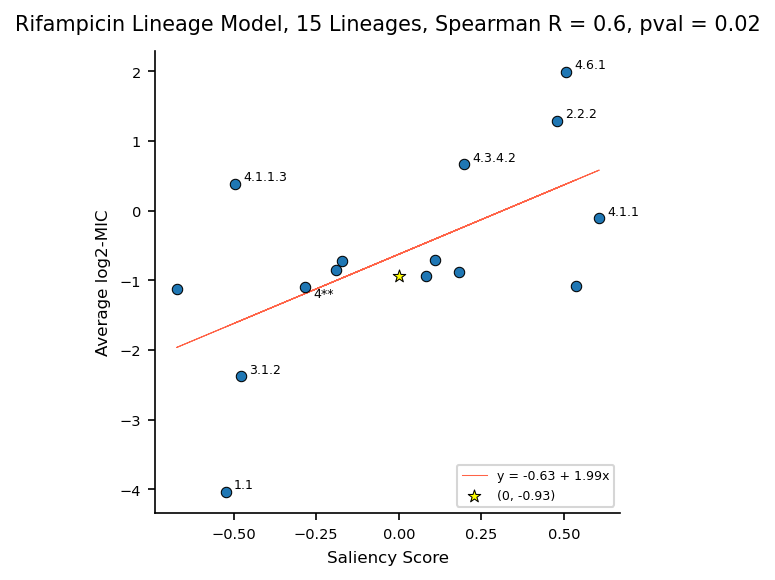

In [34]:
RIF_lineage_scores_df = generate_lineage_saliency_plot("Rifampicin",
                                                       "RIF", 
                                                       "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoBC_lineage", 
                                                       df_rif, 
                                                       binary_thresh=0.5,
                                                       sig_thresh=0.05,
                                                       significance=True,
                                                       binary=False, 
                                                       savefName="../analysis/Rifampicin/lineage_scatter.png"
                                                     )

RIF_lineage_scores_df.to_csv("../analysis/Rifampicin/significant_lineage_saliency_scores.csv", index=False)

Mean MIC: 0.4293547943320952, Mean log2-MIC: -3.063541858435793
34/62 lineages are significant
16/34 saliency-significant lineages have average MICs significantly different from the mean
Predicted log2-MIC for saliency = 0: [-3.16473703]


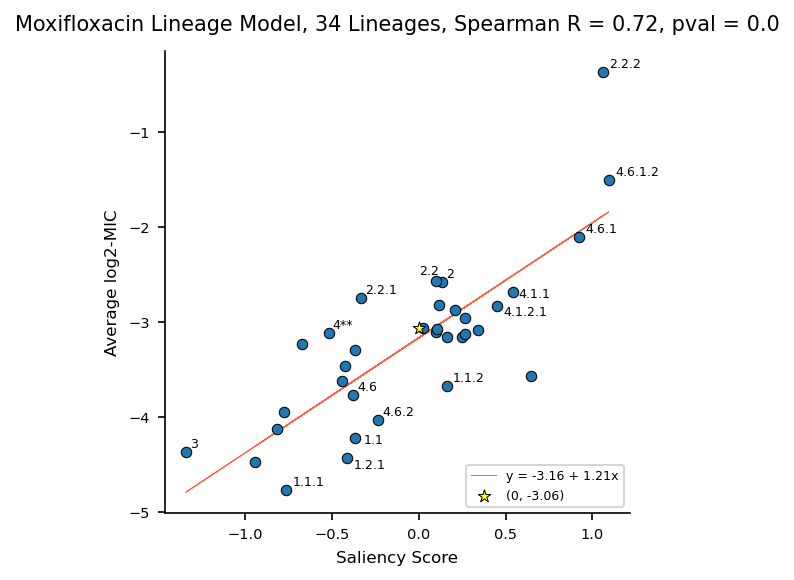

In [49]:
MXF_lineage_scores_df = generate_lineage_saliency_plot("Moxifloxacin",
                                                        "MXF", 
                                                      "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_gyrBA_lineage", 
                                                       df_mxf, 
                                                       binary_thresh=0.5,
                                                       sig_thresh=0.05,
                                                       significance=True,
                                                       binary=False, 
                                                       savefName="../analysis/Moxifloxacin/lineage_scatter.png"
                                                     )

MXF_lineage_scores_df.to_csv("../analysis/Moxifloxacin/significant_lineage_saliency_scores.csv", index=False)

# MXF_lineage_scores_df = MXF_lineage_scores_df.merge(MXF_lineage_pred, on="Lineage")

# MXF_lineage_scores_df.loc[MXF_lineage_scores_df["Lineage"]=="H37Rv", "log2-MIC"] = np.log2(df_mxf["MXF_midpoint"].min())

# Is MIC Significantly Elevated in Certain Lineages

In [299]:
RIF_sig_lineage_scores_df.query("Lineage in ['4.2.1', '2.2.1']")

,position,Max,Min,Lineage,Max_pval,Min_pval,BH_Max_pval,BH_Min_pval,log2-MIC,MIC_enrich_pval,BH_MIC_enrich_pval,plot_score
3,783601,-0.0,-0.393883,4.2.1,0.1,0.0,0.344444,0.0,0.510582,0.000498,0.001029,-0.393883
4,797736,-0.0,-0.223559,2.2.1,0.4,0.0,0.590476,0.0,-0.853869,0.457839,0.535586,-0.223559


In [287]:
RIF_sig_lineage_scores_df.query("BH_MIC_enrich_pval < 0.05")

,position,Max,Min,Lineage,Max_pval,Min_pval,BH_Max_pval,BH_Min_pval,log2-MIC,MIC_enrich_pval,BH_MIC_enrich_pval,plot_score
1,346693,0.741299,0.000000,2.2.2,0.0,0.6,0.000000,0.676364,1.292509,6.141254e-16,4.759472e-15,0.741299
2,514245,0.691994,0.000000,4.1.1,0.0,0.6,0.000000,0.676364,-0.111073,8.549601e-06,2.304675e-05,0.691994
6,1882180,-0.000000,-0.669186,BOV_AFRI,0.6,0.0,0.641379,0.000000,-4.199761,5.087022e-06,1.470124e-05,-0.669186
7,2831482,-0.000000,-0.655679,BOV,0.6,0.0,0.641379,0.000000,-4.199761,5.087022e-06,1.470124e-05,-0.655679
8,3021283,-0.000000,-0.317414,1.1.1,0.3,0.0,0.581250,0.000000,-4.897060,2.157014e-53,4.457829e-52,-0.317414
9,3216553,-0.000000,-0.364554,1.1.1.1,0.5,0.0,0.620000,0.000000,-4.959214,9.729504e-46,1.508073e-44,-0.364554
12,4260268,0.444209,0.000000,4.6.1,0.0,0.9,0.000000,0.914754,1.988988,1.512227e-06,5.515181e-06,0.444209
13,4404247,-0.000000,-0.363112,1.1,0.5,0.0,0.620000,0.000000,-4.045164,1.138472e-65,7.058529e-64,-0.363112


In [ ]:
# nice! does not co-occur with canonical gyrBA mutations
plot_variant_mics("gyrBA", 7566, moxi_gyrBA_seq_dict, df_moxi, isolates_with_gyrBA_mut, title="../Figures/gyrBA_7566_mic_dist.png")

In [ ]:
# too few isolates: only 5 with gyrBA or the variant at all. Also not convincing with the shift
# plot_variant_mics("gyrBA", 7521, moxi_gyrBA_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
# not super convincing. 22 total isolates, but gyrBA variants seem to be higher
# 6735, 6737, 6749
plot_variant_mics("gyrBA", 6735, moxi_gyrBA_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
plot_variant_mics("gyrBA", 8164, moxi_gyrBA_seq_dict, df_moxi, isolates_with_gyrBA_mut, title="../Figures/gyrBA_8164_mic_dist.png")

# Moxifloxacin Multiloci Models

In [ ]:
# moxi_gyrBA_6Loci_df, moxi_gyrBA_6Loci_seq_dict = generate_saliency_plots("config_moxi_6Loci.yaml",
#                                                              ["MXF"],
#                                                              cat_to_check=["1", "2"],
#                                                              binary=False,
#                                                              isolate_variants_df=None,
#                                                              num_bootstrap=1, 
#                                                              save=True
#                                                             )

# Bedaquiline

In [ ]:
# bdq_no_lineage_df, bdq_no_lineage_seq_dict = generate_saliency_plots("config_bdq_old.yaml",
#                                                              ["BDQ"],
#                                                              cat_to_check=["1", "2"],
#                                                              binary=False,
#                                                              isolate_variants_df=None,
#                                                              num_bootstrap=1, 
#                                                              save=True
#                                                             )

In [ ]:
who_single_drug = who_variants.query("drug=='RIF'")

who_pos = who_single_drug["genome_index"].str.split(",", expand=True)
who_pos.columns = ["pos1", "pos2"]

who_single_drug = pd.concat([who_single_drug, who_pos], axis=1).reset_index(drop=True)
print(who_single_drug.shape)

In [ ]:
for i, row in who_single_drug.iterrows():
    
    if not pd.isnull(row["pos2"]):
        
        # duplicate the row and make pos1 to pos2 in the duplicate
        add_row = who_single_drug.iloc[i, :]
        add_row["pos1"] = row["pos2"]
        
        who_single_drug = pd.concat([who_single_drug, pd.DataFrame(add_row).T], axis=0)
        
who_single_drug = who_single_drug.reset_index(drop=True)
del who_single_drug["pos2"]
del who_single_drug["genome_index"]
print(who_single_drug.shape)
who_single_drug.rename(columns={"pos1": "Pos"}, inplace=True)
who_single_drug["Pos"] = who_single_drug["Pos"].astype(float).astype(object)

In [ ]:
# get all sites with positive saliency scores
rif_resistance_analysis = rif_rpoBC_df.query("Max > 0 & max_pVal < 0.05").merge(who_single_drug, on="Pos", how="outer").sort_values("Max", ascending=False)

rif_resistance_analysis = rif_resistance_analysis.query("gene in ['rpoB', 'rpoC']").reset_index(drop=True)

del rif_resistance_analysis["Unnamed: 0"]
print(rif_resistance_analysis.shape)

#new_pos = rif_resistance_analysis.query("confidence in ['3) Uncertain significance', '5) Not assoc w R']")
new_pos = rif_resistance_analysis.loc[(~pd.isnull(rif_resistance_analysis["Max"])) & (rif_resistance_analysis["confidence"] == '3) Uncertain significance')]

print(new_pos.shape)

In [ ]:
for i, row in new_pos.iterrows():
    
    ref = rif_rpoBC_seq_dict["rpoBC"].loc["MT_H37Rv", row["Pos"]]
    alt = rif_rpoBC_seq_dict["rpoBC"][row["Pos"]] != ref
    new_pos.loc[i, "Num_Isolates"] = sum(alt)
    
# new_pos = new_pos.query("Num_Isolates > 5").reset_index(drop=True)
new_pos["Num_Isolates"] = new_pos["Num_Isolates"].astype(int) 
print(new_pos.shape)

In [ ]:
new_pos.sort_values(["Num_Isolates", "Max"], ascending=False)

In [ ]:
drug = "RIF"
locus = "rpoBC"
pos = 761880.0
cc = 0.5

for _, row in new_pos.drop_duplicates("Pos").sort_values(["Num_Isolates", "Max"], ascending=False).iterrows():
    plot_variant_mics(drug, locus, row["Pos"], rif_rpoBC_seq_dict, df_rif, isolates_with_rpoBC_mut, cc, title=None)

In [ ]:
# rif_rpoABC_df, rif_rpoABC_seq_dict = generate_saliency_plots("config_rif_multiLoci.yaml",
#                                                              ["RIF"],
#                                                              cat_to_check=["1", "2"],
#                                                              binary=False,
#                                                              isolate_variants_df=None,
#                                                              num_bootstrap=1, 
#                                                              save=True
#                                                             )

In [ ]:
# drug = "RIF"
# locus = "rpoA"
# pos = 3878575.0
# cc = 0.5

# plot_variant_mics(drug, locus, pos, rif_rpoABC_seq_dict, df_rif, isolates_with_rpoBC_mut, cc, title=None)

In [ ]:
# rif_rpoABC_Rv2752c_df, rif_rpoABC_Rv2752c_seq_dict = generate_saliency_plots("config_rif.yaml",
#                                                                              ["RIF"],
#                                                                              cat_to_check=["1", "2"],
#                                                                              binary=False,
#                                                                              isolate_variants_df=None,
#                                                                              num_bootstrap=1, 
#                                                                              save=True
#                                                                             )

In [ ]:
# rif_rpoBC_lineage_df, rif_rpoBC_lineage_seq_dict = generate_saliency_plots("config_rif_lineage.yaml",
#                                                              ["RIF"],
#                                                              cat_to_check=["1", "2"],
#                                                              binary=False,
#                                                              isolate_variants_df=None,
#                                                              num_bootstrap=1, 
#                                                              save=True
#                                                             )

In [ ]:
def two_sample_mean_bootstrap(variant_mics, no_variant_mics, num_bootstrap=1000):
    '''
    Want log2(fold change) > 1. 
    '''
    
    if len(variant_mics) > 0 and len(no_variant_mics) > 0:
        bs_res = []
        #test_stat = np.mean(variant_mics) - np.mean(no_variant_mics)
        test_stat = np.log2(np.mean(variant_mics) / np.mean(no_variant_mics))

        # do bootstrapping of difference in means. Randomly sample isolates from the two groups, then compute the mean difference in MIC between them
        for _ in range(num_bootstrap):

            # draw bootstraps
            variant_sample = np.random.choice(variant_mics, np.max([len(variant_mics), num_bootstrap]), replace=True)
            no_variant_sample = np.random.choice(no_variant_mics, np.max([len(no_variant_mics), num_bootstrap]), replace=True)

            # get the test statistic and add it to a running list
            #stat = np.mean(variant_sample) - np.mean(no_variant_sample)
            stat = np.log2(np.mean(variant_sample) / np.mean(no_variant_sample))
            bs_res.append(stat)
    else:
        test_stat = np.nan
        bs_res = np.ones(num_bootstrap) * np.nan
        
    return test_stat, np.array(bs_res)

In [ ]:
def plot_variant_mics(drug, locus, variant, mat_seq_dict, df_phenos, isolates_with_canonical_mut, cc, title=None):
    
    # sns.color_palette("Set2").as_hex()[0]
    palette = "Set1"
    color_dict = {"no variants": sns.color_palette(palette).as_hex()[-1], 
                  "variant only": sns.color_palette(palette).as_hex()[1],
                  "canonical mut only": sns.color_palette(palette).as_hex()[4],
                  "canonical mut + variant": sns.color_palette(palette).as_hex()[0]
                 }
        
    ref = mat_seq_dict[locus].loc["MT_H37Rv", variant]
    isolates_with_variant = mat_seq_dict[locus].loc[mat_seq_dict[locus][variant] != ref, variant].index.values
    
    isolates_both = list(set(isolates_with_canonical_mut).intersection(isolates_with_variant))
    isolates_variant_only = list(set(isolates_with_variant) - set(isolates_with_canonical_mut))
    isolates_canonical_only = list(set(isolates_with_canonical_mut) - set(isolates_with_variant))
    
    isolates_nothing_1 = list(set(df_phenos["ROLLINGDB_ID"]) - set(isolates_both) - set(isolates_variant_only) - set(isolates_canonical_only))
    isolates_nothing_2 = list(set(df_phenos["ROLLINGDB_ID"]) - set(isolates_with_canonical_mut) - set(isolates_with_variant))
    assert len(isolates_nothing_1) == len(isolates_nothing_2) == len(set(isolates_nothing_1).intersection(isolates_nothing_2))
        
    df_phenos.loc[df_phenos["ROLLINGDB_ID"].isin(isolates_nothing_1), "Variant"] = 'no variants'
    df_phenos.loc[df_phenos["ROLLINGDB_ID"].isin(isolates_both), "Variant"] = 'canonical mut + variant'
    df_phenos.loc[df_phenos["ROLLINGDB_ID"].isin(isolates_variant_only), "Variant"] = 'variant only'
    df_phenos.loc[df_phenos["ROLLINGDB_ID"].isin(isolates_canonical_only), "Variant"] = 'canonical mut only'
                            
    # print("There are no isolates without canonical variants, but with the variant of interest")
    if ~('variant only' not in df_phenos["Variant"].value_counts().index.values):
        df_phenos["log-MIC"] = np.log(df_phenos[f"{drug}_midpoint"])
        if (len(df_phenos.query("Variant == 'variant only'")) > 0) & (len(df_phenos.loc[(df_phenos["Variant"] == 'variant only') & (df_phenos[f"{drug}_midpoint"] > cc)]) > 1):
            print(df_phenos.groupby("Variant")[f"{drug}_midpoint"].mean())
            print(df_phenos["Variant"].value_counts())

            fig, ax = plt.subplots(1, 1, figsize=(12, 4))
            g = sns.histplot(data=df_phenos, x="log-MIC", hue='Variant', 
                             stat='probability', common_norm=False, multiple='dodge', 
                             hue_order=["no variants", 'canonical mut only', "variant only", 'canonical mut + variant'], 
                             palette=color_dict, ax=ax)

            plt.xlabel("MIC (μg/mL)")
            plt.xticks(ticks=ax.get_xticks(), labels=np.round(np.exp(ax.get_xticks()), 2).astype(str))
            ax.set_title(f"{drug} MIC Distribution for Variants at Position {int(variant)}")

            sns.move_legend(ax, "upper left", title=None)
            sns.despine()

            if title is None:
                plt.show()
            else:
                plt.savefig(title, dpi=300)
        # else:
        #     print(f"There are no isolates with only a variant at {variant}")

In [ ]:
def filter_saliencies(saliency_df, mat_seq_dict, drug, df_phenos):
    
    # get positions with non-zero scores
    nonZero = saliency_df.query("Max != 0 | Min != 0")
    
    # find the number of isolates with 
    for i, row in nonZero.iterrows():
        df = mat_seq_dict[row["Gene"]]
        if len(df[row["Pos"]].unique()) > 1:
            nonZero.loc[i, "Variant"] = 1
        else:
            nonZero.loc[i, "Variant"] = 0

    nonZero_analysis = nonZero.query("Variant == 1").sort_values("Max", ascending=False)
    
    for i, row in nonZero_analysis.iterrows():

        gene = row["Gene"]
        pos = row["Pos"]
        ref = mat_seq_dict[gene].loc["MT_H37Rv", pos]

        isolates_with_variant = mat_seq_dict[gene].loc[mat_seq_dict[gene][pos] != ref, pos].index.values

        if len(isolates_with_variant) >= 5:
            phenos_variant = df_phenos.query("ROLLINGDB_ID in @isolates_with_variant")[f"{drug}_midpoint"].values
            phenos_no_variant = df_phenos.query("ROLLINGDB_ID not in @isolates_with_variant")[f"{drug}_midpoint"].values

            stat, bootstrap_reps = two_sample_mean_bootstrap(phenos_variant, phenos_no_variant, num_bootstrap=100)
            lower, upper = np.percentile(bootstrap_reps, q=[2.5, 97.5])

            nonZero_analysis.loc[i, ["log2_FC", "log2_FC_LB", "log2_FC_UB"]] = stat, lower, upper
        else:
            nonZero_analysis.loc[i, ["log2_FC", "log2_FC_LB", "log2_FC_UB"]] = np.nan, np.nan, np.nan
            
    return nonZero_analysis.dropna(axis=0, how="any")

In [ ]:
df_moxi.query("gyrBA_mut==0").to_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/20220929_no_gyrBACanonicalMut.csv", index=False)

In [ ]:
test = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/20220929_no_gyrBACanonicalMut.csv")

In [ ]:
test.shape

In [ ]:
4819/(4819+1198)

In [ ]:
1198/(4819+1198)

In [ ]:
df_moxi.query("gyrBA_mut==0").groupby("category")["MOXI_midpoint"].mean()

In [ ]:
df_moxi.query("ROLLINGDB_ID not in @isolates_with_gyrBA_mut").MOXI_midpoint.max()

In [ ]:
df_moxi.query("ROLLINGDB_ID in @isolates_with_gyrBA_mut").MOXI_midpoint.max()

In [ ]:
#plot_variant_mics("Rv3361c_Rv3365c", 3774261, moxi_4Loci_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
#plot_variant_mics("Rv3561_Rv3565", 4005357.0, moxi_4Loci_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
#plot_variant_mics("Rv3561_Rv3565", 4004893.0, moxi_4Loci_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
moxi_isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/isolate_variants.csv")

# Moxifloxacin Multi-Loci

In [ ]:
locus_list = ['gyrBA', 'Rv0981_Rv0984', 'Rv3361c_Rv3365c', 'Rv3561_Rv3565'] 
moxi_4loci_df, moxi_4Loci_seq_dict = generate_saliency_plots("MOXI", 
                                                                 locus_list, 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/20220928_moxi_4Loci", 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/fastas", 
                                                                 ["MXF"], 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/20220902_data_clean.csv",
                                                                 cat_to_check=["1", "2"],
                                                                 isolate_variants_df=None,
                                                                 num_bootstrap=1000, 
                                                                 save=False
                                                                )

In [ ]:
locus_list = ['gyrBA', 'Rv0981_Rv0984', 'Rv2836c_Rv2837c', 'Rv3361c_Rv3365c', 'Rv0014c_Rv0015c', 'arfABC', 'phoPR', 'mbtK', 'Rv3561_Rv3565', 'stp', 'Rv0053_Rv0058', 'ligD_Rv0939'] 
# definitely remove: phoPR, stp, mbtK, Rv2836c_Rv2837c (dinF)
# next tier: arfABC, Rv0014c_Rv0015c

# generally good agreement between low saliency and not much contribution to MAE reduction

moxi_12loci_df, moxi_12Loci_seq_dict = generate_saliency_plots("MOXI", 
                                                                 locus_list, 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/20220907_moxi_12Loci", 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/fastas", 
                                                                 ["MXF"], 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/20220902_data_clean.csv",
                                                                 cat_to_check=["1", "2"],
                                                                 isolate_variants_df=None,
                                                                 num_bootstrap=1000, 
                                                                 save=False
                                                                )

# Analysis of Positions from Multi-Gene Model

In [ ]:
def validate_with_MIC_dist(locus, variant_col, mat_seq_dict, df_phenos, isolates_with_gyrBA_mut, num_bootstrap=1000):
    
    # check for significantly positive confidence intervals for all 3 groups -- isolates with canonical gyrBA mutations, isolates without, and all isolates
    ci_no_gyrBA, ci_gyrBA = plot_variant_mics(locus, variant_col, mat_seq_dict, df_phenos, isolates_with_gyrBA_mut, num_bootstrap=num_bootstrap, plot=False)
    #ci_all = plot_variant_mics_full_dist(locus, variant_col, mat_seq_dict, df_phenos, plot=False)
    
    # if at least one of them is significantly positive, keep that variant    
    cis_lst = [ci_no_gyrBA, ci_gyrBA]
    
    sig_bool = False
    for ci in cis_lst:
        
        if ci[0] > 0 and ci[1] > 0:
            sig_bool = True
            break
            
    if sig_bool:
        return 1
    else:
        return 0

In [ ]:
def filter_saliencies_by_seq_quality(var, gene, seq_dict, isolate_variants_df):
    
    ref_allele = seq_dict[gene].loc["MT_H37Rv", var]
    alt_alleles = seq_dict[gene].loc[seq_dict[gene][var] != ref_allele, var].unique()
    
    if type(var) in [float, int]:
        print("Pos found")
        # more than half of the variants must have passed QC
        if isolate_variants_df.query("POS == @var").QC.fillna(0).mean() > 0.5:
            # print(isolate_variants_df.query("POS == @var").QC.value_counts())
            print(isolate_variants_df.query("POS == @var").Isolate.unique())
        
    elif var.isnumeric():
        print("Pos found")
        print(isolate_variants_df.query("POS == @var").Isolate.unique())
        
    # insertion relative to H37Rv
    else:  
        if ref_allele == '-':
            var_pos = np.where(seq_dict[gene].columns == var)[0][0]
            prev_pos = seq_dict[gene].columns[var_pos-1]
            
            if isolate_variants_df.query("POS == @prev_pos").QC.fillna(0).mean() > 0.5:
                # print(isolate_variants_df.query("POS == @var").QC.value_counts())
                print(isolate_variants_df.query("POS == @prev_pos").Isolate.unique())

## The next 2 cells aren't needed because they don't significantly improve interpretation of results

In [ ]:
# # Merging promoters for plus strand
# promoter_location_data1 = pd.read_csv("../inputs/promoters_plus_strand.csv")
# data = promoter_location_data1.sort_values("upstream")[["downstream_gene", "position_upstream", "site", "upstream", "downstream"]]
# output_data =  []
# tracked_row = list(data.iterrows())[0][1]
# current_end = 74

# for idx, row in data.iterrows():

#     if row.upstream <= current_end:
#         # merging triggered
#         current_end = row.downstream
#     else:
#         tracked_row["downstream"] = current_end
#         output_data.append(tracked_row)
#         tracked_row = row
#         current_end = row.downstream
        
# output_data = pd.DataFrame(output_data)  
# output_data = output_data.iloc[1::,]
# print(len(data), len(output_data))
# promoter_location_data1= output_data

# # Merging promoters for minus strand
# promoter_location_data2 = pd.read_csv("../inputs/promoters_minus_strand.csv")
# data = promoter_location_data2.sort_values("upstream")[["downstream_gene", "position_upstream", "site", "upstream", "downstream"]]
# data = data.rename({
#     "upstream": "downstream",
#     "downstream": "upstream"
# }, axis = 1)
# output_data =  []
# tracked_row = list(data.iterrows())[0][1]
# current_end = 0

# for idx, row in data.iterrows():

#     if row.upstream <= current_end:
#         # merging triggered
#         current_end = row.downstream
#     else:
#         tracked_row["downstream"] = current_end
#         output_data.append(tracked_row)
#         tracked_row = row
#         current_end = row.downstream
        
# output_data = pd.DataFrame(output_data)  
# output_data = output_data.iloc[1::,]
# output_data = output_data.rename({
#     "upstream": "downstream",
#     "downstream": "upstream"
# }, axis = 1)
# print(len(data), len(output_data))
# promoter_location_data2= output_data

In [ ]:
# Add promoter annotations to genome
# H37Rv Genome

# for idx,row in promoter_location_data1.iterrows():
#     #Plus strand promoters
#     annotate_biopython_record(record, location=(
#         row.upstream, row.downstream, 1
#     ), feature_type="promoter")
    
# for idx,row in promoter_location_data2.iterrows():
#     #Plus strand promoters
#     annotate_biopython_record(record, location=(
#         row.downstream, row.upstream, -1
#     ), feature_type="promoter")